In [9]:
!pip install -r /Users/nutthaweecharoenngampis/Developer/sentiment-stock-predictor/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.2 MB/s  0:00:00 eta 0:00:01


In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from datetime import datetime

tickers = ['NVDA']
data = yf.download(tickers, start="2015-07-21", end=datetime.now(), auto_adjust=False)
# Check the data
print(tabulate(data.tail(10), headers='keys', tablefmt='psql'))

[*********************100%***********************]  1 of 1 completed

+---------------------+-------------------------+---------------------+--------------------+-------------------+--------------------+----------------------+
| Date                |   ('Adj Close', 'NVDA') |   ('Close', 'NVDA') |   ('High', 'NVDA') |   ('Low', 'NVDA') |   ('Open', 'NVDA') |   ('Volume', 'NVDA') |
|---------------------+-------------------------+---------------------+--------------------+-------------------+--------------------+----------------------|
| 2025-07-23 00:00:00 |                  170.78 |              170.78 |             171.26 |            167.97 |             169.53 |          1.54082e+08 |
| 2025-07-24 00:00:00 |                  173.74 |              173.74 |             173.83 |            171.3  |             172.44 |          1.28985e+08 |
| 2025-07-25 00:00:00 |                  173.5  |              173.5  |             174.72 |            172.96 |             173.61 |          1.22317e+08 |
| 2025-07-28 00:00:00 |                  176.75 |         

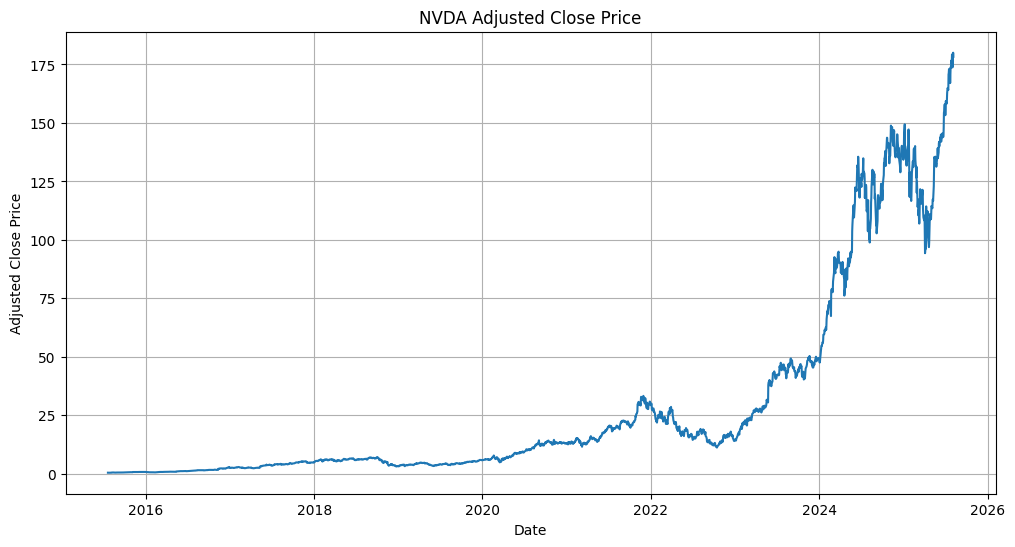

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[('Adj Close', 'NVDA')])
plt.title('NVDA Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.show()

### Train with DA-RNN old price

/Users/nutthaweecharoenngampis/Developer/sentiment-stock-predictor/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/nutthaweecharoenngampis/Developer/sentiment-stock-predictor/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([12, 1])) that is different to the input size (torch.Size([12])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1, Loss: 0.0880
Epoch 2, Loss: 0.1084
Epoch 3, Loss: 0.1004
Epoch 4, Loss: 0.0591
Epoch 5, Loss: 0.0156
Epoch 6, Loss: 0.0054
Epoch 7, Loss: 0.0066
Epoch 8, Loss: 0.0059
Epoch 9, Loss: 0.0090
Epoch 10, Loss: 0.0112
Epoch 11, Loss: 0.0127
Epoch 12, Loss: 0.0052
Epoch 13, Loss: 0.0059
Epoch 14, Loss: 0.0059
Epoch 15, Loss: 0.0095
Epoch 16, Loss: 0.0137
Epoch 17, Loss: 0.0145
Epoch 18, Loss: 0.0053
Epoch 19, Loss: 0.0048
Epoch 20, Loss: 0.0055
Epoch 21, Loss: 0.0053
Epoch 22, Loss: 0.0085
Epoch 23, Loss: 0.0125
Epoch 24, Loss: 0.0130
Epoch 25, Loss: 0.0064
Epoch 26, Loss: 0.0091
Epoch 27, Loss: 0.0108
Epoch 28, Loss: 0.0113
Epoch 29, Loss: 0.0058
Epoch 30, Loss: 0.0078


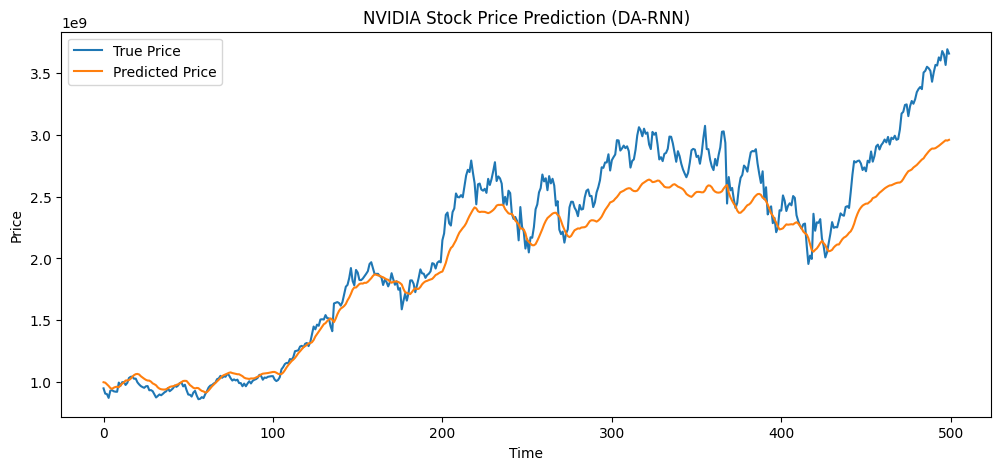

In [31]:
# Filter relevant features
df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.dropna(inplace=True)

# Normalize the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame for easier handling
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)



def create_sequences(data, target_column, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(data.iloc[i+window_size][target_column])
    return np.array(X), np.array(y)

window_size = 30  # You can tune this
X, y = create_sequences(scaled_df, target_column='Close', window_size=window_size)



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # Do not shuffle time series
)



import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        out, h = self.rnn(x)
        return out, h

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        out, _ = self.rnn(x, h)
        out = self.fc(out[:, -1, :])
        return out

class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size)
        self.decoder = Decoder(hidden_size)

    def forward(self, x):
        _, h = self.encoder(x)
        decoder_input = torch.zeros((x.size(0), 1, 1)).to(x.device)
        output = self.decoder(decoder_input, h)
        return output.squeeze()
    


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DA_RNN(input_size=X.shape[2], hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                           torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_data, batch_size=32, shuffle=False)

# Training loop
for epoch in range(30):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")



model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred = model(X_test_tensor).cpu().numpy()

# Rescale predictions
true = scaler.inverse_transform(np.concatenate([
    np.zeros((len(y_test), scaled_df.shape[1]-1)), y_test.reshape(-1,1)
], axis=1))[:, -1]

pred = scaler.inverse_transform(np.concatenate([
    np.zeros((len(y_pred), scaled_df.shape[1]-1)), y_pred.reshape(-1,1)
], axis=1))[:, -1]

plt.figure(figsize=(12,5))
plt.plot(true, label='True Price')
plt.plot(pred, label='Predicted Price')
plt.title('NVIDIA Stock Price Prediction (DA-RNN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

### Future forecasting with DA-RNN

1. Downloading stock data...


/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_47898/3983339600.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


2. Adding Moving Average features...
3. Normalizing data...
4. Preparing dataset for training...
5. Initializing DA-RNN model...
6. Training model...
Epoch 1/20, Loss: 0.550193
Epoch 5/20, Loss: 0.225821
Epoch 10/20, Loss: 0.016552
Epoch 15/20, Loss: 0.013844
Epoch 20/20, Loss: 0.014169
7. Predicting future prices...
8. Inverse transforming predictions...
9. Generating plot...


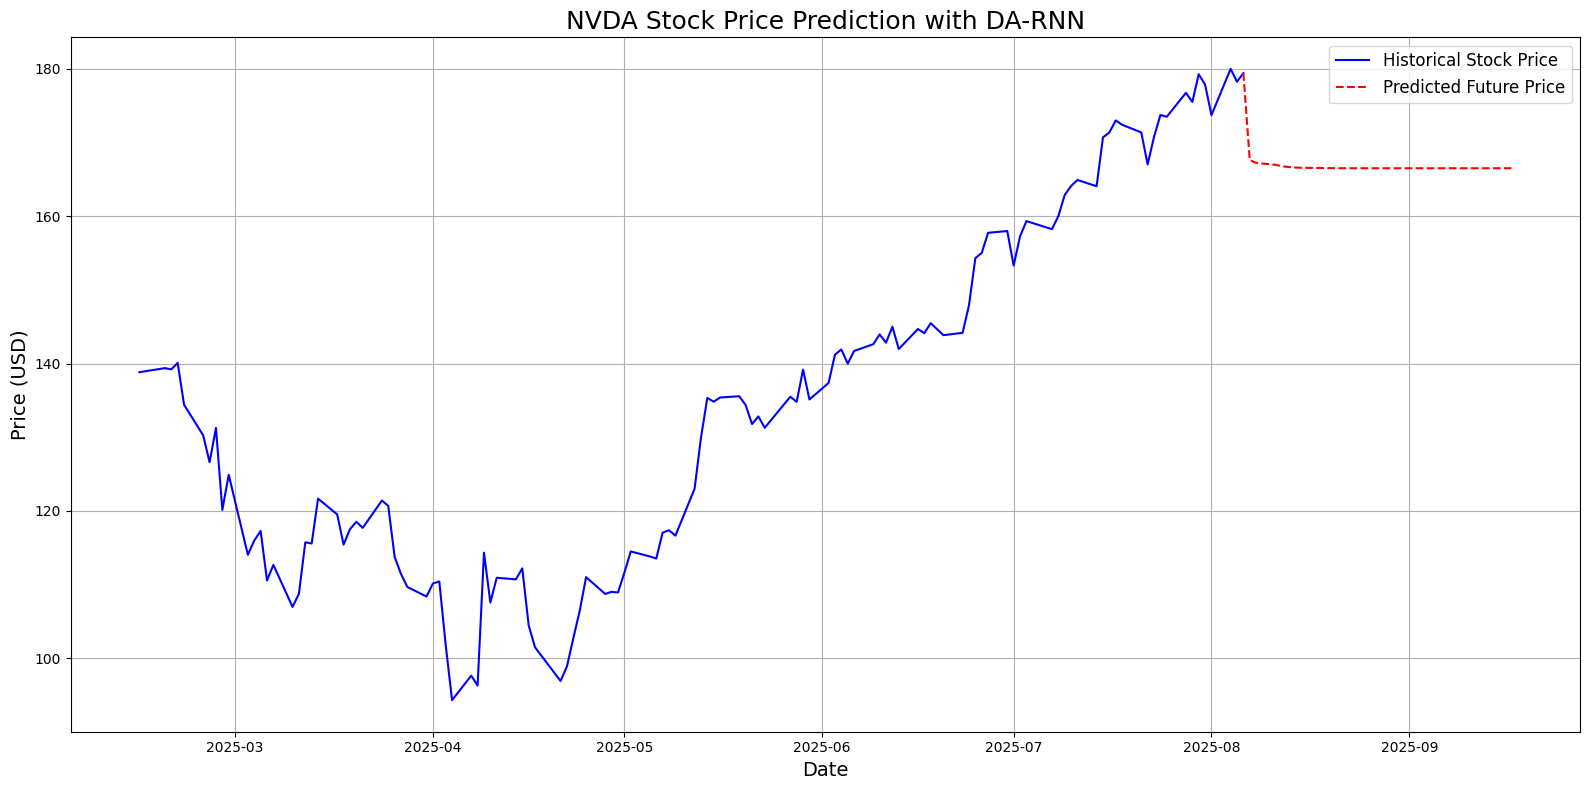

In [54]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- 1. Load Data --------------------
print("1. Downloading stock data...")
ticker = 'NVDA'
# The user's provided start date is "2025-01-01" which we will use.
# The end date will be the current day.
start_date = "2025-01-01"
end_date = datetime.now()

# Download data for NVDA from the specified start date to the present
df = yf.download(ticker, start=start_date, end=end_date)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# -------------------- 2. Feature Engineering (add MA7 and MA30) --------------------
# Moving Averages are common technical indicators used in stock analysis.
print("2. Adding Moving Average features...")
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()
df = df.dropna()

# -------------------- 3. Normalize Data --------------------
# We need to normalize the data so that the neural network can learn
# more effectively without being biased by large values (like Volume).
print("3. Normalizing data...")
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# We'll also create a scaler for just the 'Close' price to inverse transform predictions later.
close_scaler = MinMaxScaler()
close_scaler.fit(df[['Close']])

# -------------------- 4. Create Dataset and DataLoader --------------------
# The StockDataset class prepares our data into sequences for the model.
# The DataLoader handles batching and shuffling.
print("4. Preparing dataset for training...")
class StockDataset(Dataset):
    def __init__(self, data, seq_len=30):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # The input is a sequence of length `seq_len`
        seq = self.data[idx:idx + self.seq_len]
        # The target is the 'Close' price one step after the sequence ends.
        target = self.data[idx + self.seq_len, 3] # 'Close' is the 4th column (index 3)
        return torch.FloatTensor(seq), torch.FloatTensor([target])

sequence_length = 30
dataset = StockDataset(scaled_data, seq_len=sequence_length)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

# -------------------- 5. Define DA-RNN Model --------------------
# This DA-RNN architecture is based on the second code block you provided,
# but adapted to be a single class for better organization.
print("5. Initializing DA-RNN model...")
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # Using a GRU as per the second code block, which can be faster than LSTM
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        out, h = self.rnn(x)
        return h # Return the final hidden state

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        # The decoder takes a single input (the predicted close price from the previous step)
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        # We use the hidden state from the encoder as the initial hidden state for the decoder.
        out, h = self.rnn(x.unsqueeze(1), h)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

# The main DA-RNN class
class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size)
        self.decoder = Decoder(hidden_size)

    def forward(self, x):
        h = self.encoder(x)
        # For training, we predict the next close price.
        # The decoder takes a single value, so we'll use a dummy input for the first step
        # and rely on the hidden state from the encoder.
        decoder_input = torch.zeros((x.size(0), 1)).to(x.device)
        output = self.decoder(decoder_input, h)
        return output

input_size = scaled_data.shape[1]
hidden_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DA_RNN(input_size=input_size, hidden_size=hidden_size).to(device)

# -------------------- 6. Train Model --------------------
print("6. Training model...")
epochs = 20
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_model(model, dataloader, epochs):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for seq, target in dataloader:
            seq, target = seq.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(seq)
            loss = criterion(output, target.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.6f}")

train_model(model, dataloader, epochs)

# -------------------- 7. Predict Future Prices --------------------
# This function iteratively predicts future prices using the trained model.
print("7. Predicting future prices...")
def predict_future(model, last_seq, n_future=30):
    model.eval()
    last_seq = last_seq.to(device)
    preds = []

    with torch.no_grad():
        for _ in range(n_future):
            # Pass the sequence through the encoder to get the hidden state
            hidden = model.encoder(last_seq)

            # Get the predicted price from the decoder
            decoder_input = torch.zeros((1, 1)).to(device) # The decoder needs an initial input
            pred = model.decoder(decoder_input, hidden)
            
            preds.append(pred.item())
            
            # The next sequence is the old sequence shifted, with the new prediction appended.
            # We need to simulate the features for the next day. A simple way is to
            # assume the Open, High, Low, Volume, MA7, and MA30 for the next day
            # are the same as the last known day.
            new_row = last_seq[0, -1, :].clone().detach()
            new_row[3] = pred.item() # Update the 'Close' price with the prediction.
            
            # Recalculate MA7 and MA30 based on the new 'Close' price, this is a
            # simplification and may not be accurate. For a real application,
            # a more sophisticated approach is needed.
            # Here we just use a simple shift.
            
            # Append the new row to the sequence
            last_seq = torch.cat((last_seq[:, 1:, :], new_row.unsqueeze(0).unsqueeze(0)), dim=1)

    return preds

last_sequence = scaled_data[-sequence_length:]
last_sequence = torch.FloatTensor(last_sequence).unsqueeze(0).to(device)
future_preds_scaled = predict_future(model, last_sequence, n_future=30)

# -------------------- 8. Inverse Transform Predictions --------------------
# We need to convert the normalized predictions back to actual dollar values.
print("8. Inverse transforming predictions...")
future_preds_scaled = np.array(future_preds_scaled).reshape(-1, 1)
future_preds_original = close_scaler.inverse_transform(future_preds_scaled)

# -------------------- 9. Plotting the Results --------------------
print("9. Generating plot...")

# Combine the historical and predicted dates for a continuous x-axis
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30, freq='B')
combined_dates = df.index.tolist() + future_dates.tolist()

# Combine the historical and predicted prices for a continuous y-axis
last_historical_price = df['Close'].iloc[-1].item()
combined_prices = df['Close'].values.tolist() + future_preds_original.flatten().tolist()

plt.figure(figsize=(16, 8))
# Plot the full combined data.
# The split is handled by setting different colors and line styles.
plt.plot(df.index, df['Close'], label='Historical Stock Price', color='blue')
# Plot the predicted prices, starting from the last historical point.
# New line 199
plt.plot(pd.Index([last_date]).append(future_dates), np.concatenate((np.array([[last_historical_price]]), future_preds_original)),
         label='Predicted Future Price', color='red', linestyle='--')

plt.title(f'{ticker} Stock Price Prediction with DA-RNN', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Using news api with DA-RNN

finnhub api key: d2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0

/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_47898/3122408405.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Fetching news from Finnhub...


Organizing news by date...
Loading sentence transformer model...


/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_47898/3122408405.py:60: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  date = datetime.utcfromtimestamp(item['datetime']).date()


Embedding news per day...
Created sequences: (221, 30, 389)
Training model...
Epoch 1/20, Loss: 0.300324
Epoch 2/20, Loss: 0.156006
Epoch 3/20, Loss: 0.071095
Epoch 4/20, Loss: 0.057851
Epoch 5/20, Loss: 0.065873
Epoch 6/20, Loss: 0.044516
Epoch 7/20, Loss: 0.048494
Epoch 8/20, Loss: 0.048063
Epoch 9/20, Loss: 0.044032
Epoch 10/20, Loss: 0.046738
Epoch 11/20, Loss: 0.043860
Epoch 12/20, Loss: 0.042172
Epoch 13/20, Loss: 0.042049
Epoch 14/20, Loss: 0.042086
Epoch 15/20, Loss: 0.041027
Epoch 16/20, Loss: 0.040205
Epoch 17/20, Loss: 0.040235
Epoch 18/20, Loss: 0.037019
Epoch 19/20, Loss: 0.035620
Epoch 20/20, Loss: 0.035020
Predicting next 30 days...


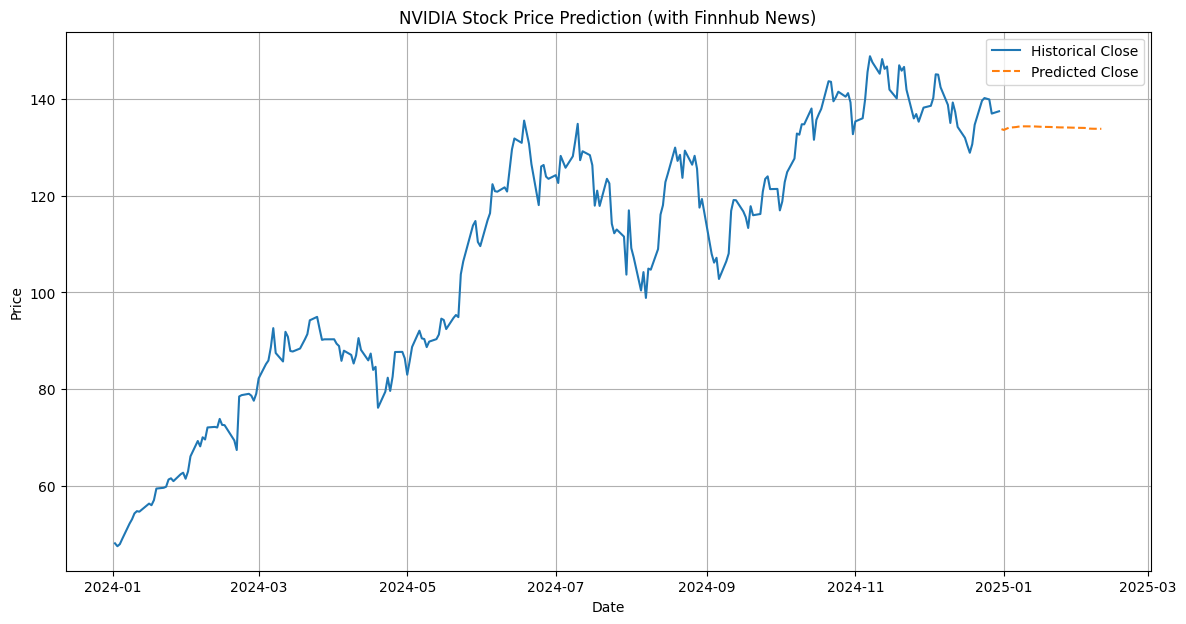

In [77]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import requests

# ------------ CONFIG --------------
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'  # Replace with your Finnhub API key
TICKER = "NVDA"
START_DATE = "2024-01-01"
END_DATE = "2024-12-31"
SEQ_LEN = 30
BATCH_SIZE = 64
HIDDEN_SIZE = 64
EPOCHS = 20

# ------------ 1. Download stock data --------------
print("Downloading stock data...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.index = pd.to_datetime(df.index)

# ------------ 2. Fetch news from Finnhub --------------
print("Fetching news from Finnhub...")

def fetch_finnhub_news(ticker, start, end, api_key):
    url = 'https://finnhub.io/api/v1/company-news'
    start_unix = int(pd.Timestamp(start).timestamp())
    end_unix = int(pd.Timestamp(end).timestamp())
    params = {
        'symbol': ticker,
        'from': start,
        'to': end,
        'token': api_key
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    news = response.json()
    return news

news_raw = fetch_finnhub_news(TICKER, START_DATE, END_DATE, FINNHUB_API_KEY)

# ------------ 3. Organize news by date --------------
print("Organizing news by date...")
news_by_date = {}

for item in news_raw:
    date_str = item['datetime'] if 'datetime' in item else None
    if not date_str:
        # fallback
        date = pd.to_datetime(item.get('datetime', None), unit='s')
    else:
        # Finnhub datetime is in UNIX timestamp seconds, so convert
        date = datetime.utcfromtimestamp(item['datetime']).date()
    headline = item.get('headline', '')
    if date not in news_by_date:
        news_by_date[date] = []
    news_by_date[date].append(headline)

# Make sure all stock dates have at least empty news list
for d in df.index.date:
    if d not in news_by_date:
        news_by_date[d] = []

# ------------ 4. Load sentence-transformers model --------------
print("Loading sentence transformer model...")
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model.eval()

def embed_sentences(sentences):
    if not sentences:
        return np.zeros(model.config.hidden_size)  # zero vector if no news
    inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.mean(dim=0).numpy()  # average across sentences

# ------------ 5. Create news embeddings aligned to stock dates --------------
print("Embedding news per day...")
news_embeddings = []
for date in df.index.date:
    daily_headlines = news_by_date.get(date, [])
    emb = embed_sentences(daily_headlines)
    news_embeddings.append(emb)
news_embeddings = np.vstack(news_embeddings)

# ------------ 6. Combine stock and news features --------------
stock_features = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
X_raw = np.hstack([stock_features, news_embeddings])

# ------------ 7. Normalize features --------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

# ------------ 8. Create sequences --------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 3])  # 'Close' price index 3
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(X_scaled, SEQ_LEN)
print(f"Created sequences: {X_seq.shape}")

# ------------ 9. Prepare PyTorch Dataset --------------
class StockNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = StockNewsDataset(X_seq, y_seq)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ------------ 10. Define DA-RNN Model --------------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
    def forward(self, x):
        _, h = self.gru(x)
        return h

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x, h):
        out, _ = self.gru(x.unsqueeze(1), h)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size)
        self.decoder = Decoder(hidden_size)
    def forward(self, x):
        h = self.encoder(x)
        dec_input = torch.zeros(x.size(0), 1).to(x.device)
        output = self.decoder(dec_input, h)
        return output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DA_RNN(X_seq.shape[2], HIDDEN_SIZE).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ------------ 11. Train --------------
print("Training model...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(dataloader):.6f}")

# ------------ 12. Predict future 30 days --------------
print("Predicting next 30 days...")
model.eval()
last_seq = torch.tensor(X_scaled[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)
future_preds = []

with torch.no_grad():
    current_seq = last_seq
    for _ in range(30):
        pred = model(current_seq)
        future_preds.append(pred.item())
        next_features = current_seq[0, -1, :].cpu().numpy()
        next_features[3] = pred.item()  # update 'Close' price with predicted
        next_features = torch.tensor(next_features, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        current_seq = torch.cat([current_seq[:, 1:, :], next_features], dim=1)

# ------------ 13. Inverse scale Close price predictions --------------
close_idx = 3
dummy = np.zeros((len(future_preds), X_seq.shape[2]))
dummy[:, close_idx] = future_preds
pred_inv = scaler.inverse_transform(dummy)[:, close_idx]

# ------------ 14. Plot --------------
plt.figure(figsize=(14,7))
plt.plot(df.index, df['Close'], label='Historical Close')
future_dates = pd.bdate_range(df.index[-1] + timedelta(days=1), periods=30)
plt.plot(future_dates, pred_inv, linestyle='--', label='Predicted Close')
plt.title("NVIDIA Stock Price Prediction (with Finnhub News)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

### how long since the news come out it will impact the actual stock price



/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/3335423218.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


Fetching news from Finnhub...


100%|██████████| 366/366 [10:51<00:00,  1.78s/it]


Loading sentence transformer model...
Embedding news per trading day...
Creating lagged news features with max lag=5...
Normalizing features...
Training model...
Epoch 1/20 - Loss: 0.337695 - Attention weights (lags): [0.4617118  0.01510163 0.04261285 0.12045363 0.25697392 0.10314584]
Epoch 2/20 - Loss: 0.053416 - Attention weights (lags): [0.461712   0.01510163 0.04261285 0.12045362 0.25697392 0.10314588]
Epoch 3/20 - Loss: 0.050295 - Attention weights (lags): [0.46171197 0.01510163 0.04261286 0.12045363 0.25697395 0.1031459 ]
Epoch 4/20 - Loss: 0.035173 - Attention weights (lags): [0.46171197 0.01510163 0.04261285 0.12045363 0.2569739  0.10314584]
Epoch 5/20 - Loss: 0.033481 - Attention weights (lags): [0.461712   0.01510163 0.04261285 0.12045362 0.25697395 0.10314584]
Epoch 6/20 - Loss: 0.033856 - Attention weights (lags): [0.46171188 0.01510163 0.04261285 0.12045366 0.25697383 0.10314584]
Epoch 7/20 - Loss: 0.030595 - Attention weights (lags): [0.46171215 0.01510163 0.04261285 0.12

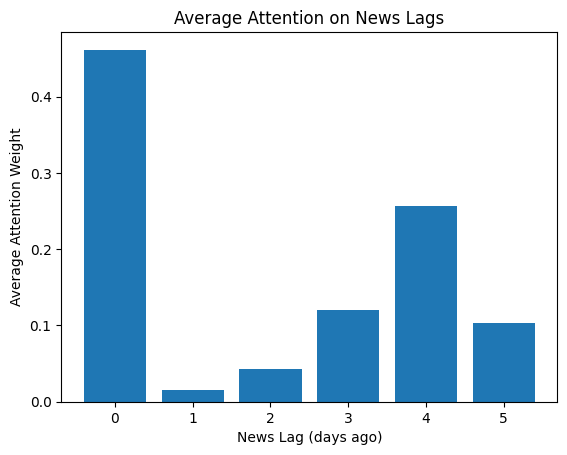

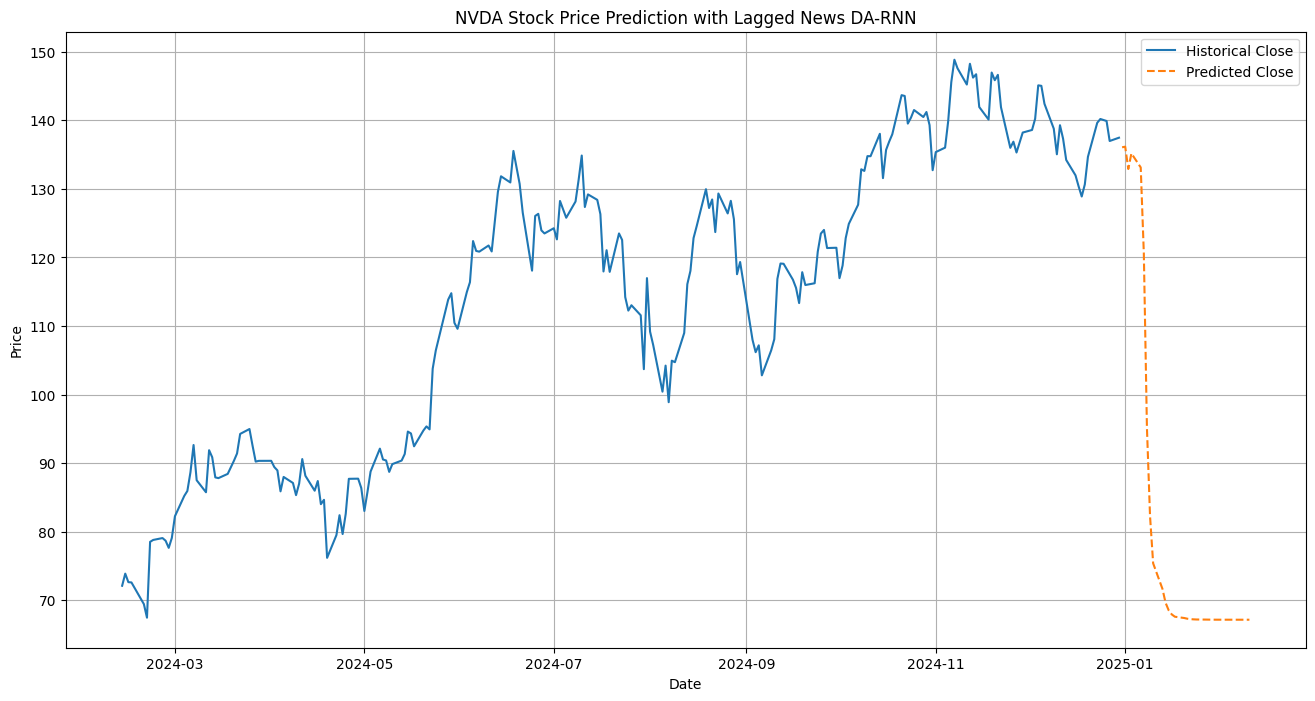

In [ ]:
import yfinance as yf
import finnhub
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F
import time
from tqdm import tqdm

# --------- Config ---------
TICKER = 'NVDA'
START_DATE = '2024-01-01'
END_DATE = '2024-12-31'
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'
MAX_LAG = 5
SEQ_LEN = 30
BATCH_SIZE = 64
HIDDEN_SIZE = 64
EPOCHS = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --------- 1. Download stock data ---------
print("Downloading stock data...")
df_stock = yf.download(TICKER, start=START_DATE, end=END_DATE)
df_stock = df_stock[['Open', 'High', 'Low', 'Close', 'Volume']]
df_stock['MA7'] = df_stock['Close'].rolling(window=7).mean()
df_stock['MA30'] = df_stock['Close'].rolling(window=30).mean()
df_stock.dropna(inplace=True)

# --------- 2. Fetch news headlines from Finnhub ---------
print("Fetching news from Finnhub...")
finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

# Finnhub free plan limits: max 50 requests/minute. We’ll fetch daily news for the date range.
dates = pd.date_range(start=START_DATE, end=END_DATE, freq='D')


news_per_day = {}
for dt in tqdm(dates):
    from_ts = int(datetime(dt.year, dt.month, dt.day).timestamp())
    to_ts = int((datetime(dt.year, dt.month, dt.day) + timedelta(days=1)).timestamp()) - 1
    try:
        news = finnhub_client.company_news(TICKER, _from=dt.strftime('%Y-%m-%d'), to=dt.strftime('%Y-%m-%d'))
        headlines = [item['headline'] for item in news if 'headline' in item]
        news_per_day[dt.date()] = headlines
    except Exception as e:
        print(f"Finnhub API error on {dt.date()}: {e}")
        news_per_day[dt.date()] = []
    time.sleep(1.3) 

# Align news dates to trading dates (stock data index)
trading_dates = df_stock.index.date

# --------- 3. Embed news headlines per day ---------
print("Loading sentence transformer model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def embed_headlines(headlines):
    if not headlines:
        return np.zeros(embedder.get_sentence_embedding_dimension())
    embeddings = embedder.encode(headlines)
    return embeddings.mean(axis=0)  # average embeddings of all headlines in a day

print("Embedding news per trading day...")
news_embeddings = []
for dt in trading_dates:
    day_headlines = news_per_day.get(dt, [])
    emb = embed_headlines(day_headlines)
    news_embeddings.append(emb)
news_embeddings = np.vstack(news_embeddings)  # shape (num_days, emb_dim)

# --------- 4. Create lagged news features ---------
print(f"Creating lagged news features with max lag={MAX_LAG}...")
def create_lagged_news_features(news_emb, max_lag=5):
    lagged_feats = []
    for lag in range(max_lag + 1):
        shifted = np.roll(news_emb, lag, axis=0)
        shifted[:lag, :] = 0  # zero pad top lag rows
        lagged_feats.append(shifted)
    return np.concatenate(lagged_feats, axis=1)

lagged_news_features = create_lagged_news_features(news_embeddings, MAX_LAG)

# --------- 5. Combine with stock features ---------
stock_features = df_stock[['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30']].values
X_full = np.hstack([stock_features, lagged_news_features])

# --------- 6. Normalize features ---------
print("Normalizing features...")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_full)

close_scaler = MinMaxScaler()
close_scaler.fit(stock_features[:, 3].reshape(-1,1))  # 'Close' only

# --------- 7. Dataset and Dataloader ---------
class StockNewsDataset(Dataset):
    def __init__(self, data, seq_len=30, target_col_idx=3):
        self.data = data
        self.seq_len = seq_len
        self.target_col_idx = target_col_idx

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        seq = self.data[idx:idx+self.seq_len]
        target = self.data[idx+self.seq_len, self.target_col_idx]
        return torch.FloatTensor(seq), torch.FloatTensor([target])

dataset = StockNewsDataset(X_scaled, seq_len=SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# --------- 8. DA-RNN with Attention on lagged news ---------
input_size = X_scaled.shape[1]
news_emb_dim = news_embeddings.shape[1]
stock_feat_len = stock_features.shape[1]

class AttentionEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, news_emb_dim, max_lag):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.news_emb_dim = news_emb_dim
        self.max_lag = max_lag
        self.stock_feat_len = stock_feat_len
        self.attn_w = nn.Parameter(torch.Tensor(max_lag + 1, news_emb_dim))
        nn.init.xavier_uniform_(self.attn_w)

    def forward(self, x):
        out, h = self.rnn(x)  # out: (batch, seq_len, hidden_size), h: (1, batch, hidden_size)

        last_timestep_feats = x[:, -1, self.stock_feat_len:]  # lagged news part
        lag_blocks = last_timestep_feats.view(-1, self.max_lag + 1, self.news_emb_dim)

        attn_scores = (lag_blocks * self.attn_w).sum(dim=2)  # (batch, max_lag+1)
        attn_weights = F.softmax(attn_scores, dim=1)

        self.attn_weights = attn_weights.detach().cpu().numpy()
        return h

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        out, h = self.rnn(x.unsqueeze(1), h)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size, news_emb_dim, max_lag):
        super().__init__()
        self.encoder = AttentionEncoder(input_size, hidden_size, news_emb_dim, max_lag)
        self.decoder = Decoder(hidden_size)

    def forward(self, x):
        h = self.encoder(x)
        decoder_input = torch.zeros((x.size(0), 1)).to(x.device)
        output = self.decoder(decoder_input, h)
        return output

model = DA_RNN(input_size, HIDDEN_SIZE, news_emb_dim, MAX_LAG).to(DEVICE)

# --------- 9. Train ---------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Training model...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    attn_collect = []
    for seq, target in dataloader:
        seq, target = seq.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        pred = model(seq)
        loss = criterion(pred, target.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Collect attention weights
        attn_collect.append(model.encoder.attn_weights)

    avg_loss = total_loss / len(dataloader)
    # Average attention weights this epoch (concatenate batches)
    attn_epoch = np.concatenate(attn_collect, axis=0).mean(axis=0)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.6f} - Attention weights (lags): {attn_epoch}")

# --------- 10. Visualize average attention weights over lags ---------
def plot_attention_weights(attn_weights, max_lag):
    plt.bar(range(max_lag+1), attn_weights)
    plt.xlabel('News Lag (days ago)')
    plt.ylabel('Average Attention Weight')
    plt.title('Average Attention on News Lags')
    plt.xticks(range(max_lag+1))
    plt.show()

plot_attention_weights(attn_epoch, MAX_LAG)

# --------- 11. Predict future 30 days ---------
def predict_future(model, last_seq, n_days=30):
    model.eval()
    preds = []
    current_seq = last_seq.clone()

    with torch.no_grad():
        for _ in range(n_days):
            h = model.encoder(current_seq)
            decoder_input = torch.zeros((1, 1)).to(DEVICE)
            pred = model.decoder(decoder_input, h)
            preds.append(pred.item())

            # Prepare next seq input by shifting and adding new row
            new_row = current_seq[0, -1, :].clone()
            # Update 'Close' price feature (index 3) with prediction
            new_row[3] = pred.item()

            # News lagged embeddings for next day: shift lag blocks by 1 day forward
            # Last lag block is zero as no future news yet
            news_feats = new_row[stock_feat_len:].view(MAX_LAG+1, news_emb_dim)
            news_feats = torch.roll(news_feats, shifts=1, dims=0)
            news_feats[0, :] = 0  # zero news today (no future news)
            new_row[stock_feat_len:] = news_feats.view(-1)

            current_seq = torch.cat([current_seq[:,1:,:], new_row.unsqueeze(0).unsqueeze(0)], dim=1)

    return np.array(preds)

last_seq = torch.FloatTensor(X_scaled[-SEQ_LEN:]).unsqueeze(0).to(DEVICE)
future_preds_scaled = predict_future(model, last_seq, 30)
future_preds = close_scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1,1))

# --------- 12. Plot historical + predicted ---------
plt.figure(figsize=(16,8))
plt.plot(df_stock.index, df_stock['Close'], label='Historical Close')
future_dates = pd.date_range(df_stock.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')
plt.plot(future_dates, future_preds, '--', label='Predicted Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'{TICKER} Stock Price Prediction with Lagged News DA-RNN')
plt.legend()
plt.grid(True)
plt.show()

### V2 


In [ ]:
import yfinance as yf
import finnhub
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F
import time
from tqdm import tqdm

# --------- Config ---------
TICKER = 'NVDA'
START_DATE = '2024-01-01'
END_DATE = '2024-12-31'
TEST_START_DATE = '2025-01-01'
TEST_END_DATE = '2025-03-15'  # Approx 30 trading days
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'  # Replace this!
MAX_LAG = 5
SEQ_LEN = 30
BATCH_SIZE = 64
HIDDEN_SIZE = 64
EPOCHS = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ACCURACY_THRESHOLD = 0.005  # Adjust this threshold as needed




# --------- Helper functions ---------

def fetch_stock_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df['MA7'] = df['Close'].rolling(window=7).mean()
    df['MA30'] = df['Close'].rolling(window=30).mean()
    df.dropna(inplace=True)
    return df

def fetch_news(ticker, start_date, end_date, finnhub_client):
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    news_per_day = {}
    for dt in tqdm(dates, desc=f"Fetching news {start_date} to {end_date}"):
        try:
            news = finnhub_client.company_news(ticker, _from=dt.strftime('%Y-%m-%d'), to=dt.strftime('%Y-%m-%d'))
            headlines = [item['headline'] for item in news if 'headline' in item]
            news_per_day[dt.date()] = headlines
        except Exception as e:
            print(f"Finnhub API error on {dt.date()}: {e}")
            news_per_day[dt.date()] = []
        time.sleep(1.3)  # Respect API rate limits
    return news_per_day

def embed_headlines_list(embedder, news_per_day, trading_dates):
    embeddings = []
    for dt in trading_dates:
        headlines = news_per_day.get(dt, [])
        if len(headlines) == 0:
            embeddings.append(np.zeros(embedder.get_sentence_embedding_dimension()))
        else:
            emb = embedder.encode(headlines)
            embeddings.append(emb.mean(axis=0))
    return np.vstack(embeddings)

def create_lagged_news_features(news_emb, max_lag=5):
    lagged_feats = []
    for lag in range(max_lag + 1):
        shifted = np.roll(news_emb, lag, axis=0)
        shifted[:lag, :] = 0
        lagged_feats.append(shifted)
    return np.concatenate(lagged_feats, axis=1)

class StockNewsDataset(Dataset):
    def __init__(self, data, seq_len=30, target_col_idx=3):
        self.data = data
        self.seq_len = seq_len
        self.target_col_idx = target_col_idx

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        seq = self.data[idx:idx+self.seq_len]
        target = self.data[idx+self.seq_len, self.target_col_idx]
        return torch.FloatTensor(seq), torch.FloatTensor([target])

def create_dataset(data, seq_len=SEQ_LEN, target_col_idx=3):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_col_idx])
    return np.array(X), np.array(y)

def download_stock_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date)
    return df

def adjust_test_period_for_seq_len(ticker, start_date, end_date, seq_len, min_sequences=1, max_extend_days=60):
    """
    Ensure there are enough trading days between start_date and end_date to generate
    at least min_sequences of sequences with length seq_len.
    If not, tries to extend the end_date by up to max_extend_days.

    Returns: (adjusted_df, adjusted_seq_len)
    """
    curr_end_date = pd.to_datetime(end_date)
    start = pd.to_datetime(start_date)
    
    while True:
        df_test = download_stock_data(ticker, start, curr_end_date)
        available_rows = len(df_test)
        # Calculate possible sequences
        possible_sequences = max(0, available_rows - seq_len)
        
        if possible_sequences >= min_sequences:
            # Enough data
            print(f"Using test period: {start_date} to {curr_end_date.date()} with {available_rows} rows.")
            return df_test, seq_len
        else:
            # Not enough sequences, try to extend end_date
            curr_end_date += pd.Timedelta(days=7)  # extend by 1 week
            if (curr_end_date - start).days > (pd.to_datetime(end_date) - start).days + max_extend_days:
                # Can't extend anymore
                # Reduce seq_len instead to fit available data
                new_seq_len = max(1, available_rows - min_sequences)
                print(f"Insufficient data for seq_len={seq_len}. Reducing seq_len to {new_seq_len} for test period {start_date} to {curr_end_date.date()}")
                return df_test, new_seq_len


# --------- Model Definition ---------

class AttentionEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, news_emb_dim, max_lag, stock_feat_len):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.news_emb_dim = news_emb_dim
        self.max_lag = max_lag
        self.stock_feat_len = stock_feat_len
        self.attn_w = nn.Parameter(torch.Tensor(max_lag + 1, news_emb_dim))
        nn.init.xavier_uniform_(self.attn_w)

    def forward(self, x):
        out, h = self.rnn(x)  # out: (batch, seq_len, hidden_size), h: (1, batch, hidden_size)

        last_timestep_feats = x[:, -1, self.stock_feat_len:]  # lagged news part
        lag_blocks = last_timestep_feats.view(-1, self.max_lag + 1, self.news_emb_dim)

        attn_scores = (lag_blocks * self.attn_w).sum(dim=2)  # (batch, max_lag+1)
        attn_weights = F.softmax(attn_scores, dim=1)

        self.attn_weights = attn_weights.detach().cpu().numpy()
        return h

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        out, h = self.rnn(x.unsqueeze(1), h)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size, news_emb_dim, max_lag, stock_feat_len):
        super().__init__()
        self.encoder = AttentionEncoder(input_size, hidden_size, news_emb_dim, max_lag, stock_feat_len)
        self.decoder = Decoder(hidden_size)

    def forward(self, x):
        h = self.encoder(x)
        decoder_input = torch.zeros((x.size(0), 1)).to(x.device)
        output = self.decoder(decoder_input, h)
        return output
    



# --------- Main Script ---------
df_test, adjusted_seq_len = adjust_test_period_for_seq_len(TICKER, TEST_START_DATE, TEST_END_DATE, SEQ_LEN)
SEQ_LEN = adjusted_seq_len

print("Downloading stock data...")
df_stock_train = fetch_stock_data(TICKER, START_DATE, END_DATE)
df_stock_test = fetch_stock_data(TICKER, TEST_START_DATE, TEST_END_DATE)

print("Fetching news from Finnhub...")
finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)
news_train = fetch_news(TICKER, START_DATE, END_DATE, finnhub_client)
news_test = fetch_news(TICKER, TEST_START_DATE, TEST_END_DATE, finnhub_client)

/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/1094412869.py:99: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/1094412869.py:37: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/1094412869.py:37: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Using test period: 2025-01-01 to 2025-03-15 with 49 rows.
Fetching news from Finnhub...


Fetching news 2024-01-01 to 2024-12-31:   7%|▋         | 26/366 [00:43<09:34,  1.69s/it]


KeyboardInterrupt: 

In [14]:
print("Loading sentence transformer model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

train_trading_dates = df_stock_train.index.date
test_trading_dates = df_stock_test.index.date

news_emb_train = embed_headlines_list(embedder, news_train, train_trading_dates)
news_emb_test = embed_headlines_list(embedder, news_test, test_trading_dates)

print(f"Creating lagged news features (max lag {MAX_LAG}) for training and testing...")
lagged_news_train = create_lagged_news_features(news_emb_train, MAX_LAG)
lagged_news_test = create_lagged_news_features(news_emb_test, MAX_LAG)

stock_features_train = df_stock_train[['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30']].values
stock_features_test = df_stock_test[['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30']].values

X_train_full = np.hstack([stock_features_train, lagged_news_train])
X_test_full = np.hstack([stock_features_test, lagged_news_test])

print("Normalizing features...")
scaler = MinMaxScaler()
X_scaled_train = scaler.fit_transform(X_train_full)
X_scaled_test = scaler.transform(X_test_full)

close_scaler = MinMaxScaler()
close_scaler.fit(stock_features_train[:, 3].reshape(-1,1))  # Only close price scaling

dataset_train = StockNewsDataset(X_scaled_train, seq_len=SEQ_LEN)
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)

input_size = X_scaled_train.shape[1]
news_emb_dim = news_emb_train.shape[1]
stock_feat_len = stock_features_train.shape[1]

model = DA_RNN(input_size, HIDDEN_SIZE, news_emb_dim, MAX_LAG, stock_feat_len).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_model(model, dataloader, optimizer, criterion, epochs=EPOCHS):
    for epoch in tqdm(range(epochs), desc="Training Epochs"):
        model.train()
        total_loss = 0
        attn_collect = []
        for seq, target in dataloader:
            seq, target = seq.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            pred = model(seq)
            loss = criterion(pred, target.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            attn_collect.append(model.encoder.attn_weights)
        avg_loss = total_loss / len(dataloader)
        attn_epoch = np.concatenate(attn_collect, axis=0).mean(axis=0)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f} - Attention weights: {attn_epoch}")
    return attn_epoch

def evaluate(model, X_test, y_test, close_scaler):
    model.eval()
    with torch.no_grad():
        inputs = torch.FloatTensor(X_test).to(DEVICE)
        preds = []
        for i in range(inputs.shape[0]):
            seq = inputs[i:i+1]
            pred = model(seq)
            preds.append(pred.item())
        preds = np.array(preds).reshape(-1, 1)
        preds_unscaled = close_scaler.inverse_transform(preds)
        y_unscaled = close_scaler.inverse_transform(y_test.reshape(-1,1))
        mse = np.mean((preds_unscaled - y_unscaled) ** 2)
        return mse, preds_unscaled, y_unscaled

# Prepare test data sequences
X_test_seq, y_test_seq = create_dataset(X_scaled_test, seq_len=SEQ_LEN)

mse_val = float('inf')
iteration = 0



print("Length of X_scaled_test:", len(X_scaled_test))
print("SEQ_LEN:", SEQ_LEN)

while mse_val > ACCURACY_THRESHOLD:
    iteration += 1
    print(f"\n--- Training iteration {iteration} ---")
    attn_epoch = train_model(model, dataloader_train, optimizer, criterion, epochs=EPOCHS)

    mse_val, preds_unscaled, y_unscaled = evaluate(model, X_test_seq, y_test_seq, close_scaler)
    print(f"Validation MSE on 2025 test data after iteration {iteration}: {mse_val:.6f}")

    if mse_val <= ACCURACY_THRESHOLD:
        print("Desired accuracy reached. Stopping training.")
        break
    else:
        print("Accuracy threshold not met, retraining...")

def plot_attention_weights(attn_weights, max_lag):
    plt.bar(range(max_lag+1), attn_weights)
    plt.xlabel('News Lag (days ago)')
    plt.ylabel('Average Attention Weight')
    plt.title('Average Attention on News Lags')
    plt.xticks(range(max_lag+1))
    plt.show()

plot_attention_weights(attn_epoch, MAX_LAG)

# Optional: plot actual vs predicted for validation period
plt.figure(figsize=(14,7))
plt.plot(df_stock_test.index[SEQ_LEN:], y_unscaled, label='Actual Close Price')
plt.plot(df_stock_test.index[SEQ_LEN:], preds_unscaled, label='Predicted Close Price', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'{TICKER} Close Price Prediction on 2025 Test Set')
plt.legend()
plt.grid(True)
plt.show()

Loading sentence transformer model...
Creating lagged news features (max lag 5) for training and testing...
Normalizing features...
Length of X_scaled_test: 20
SEQ_LEN: 30

--- Training iteration 1 ---


Training Epochs:  10%|█         | 2/20 [00:00<00:01, 14.31it/s]

Epoch 1/20 - Loss: 0.235628 - Attention weights: [0.10080024 0.42002463 0.08465932 0.06484132 0.25110915 0.0785655 ]
Epoch 2/20 - Loss: 0.040805 - Attention weights: [0.10080022 0.42002454 0.08465933 0.06484132 0.25110912 0.07856549]
Epoch 3/20 - Loss: 0.035333 - Attention weights: [0.10080024 0.42002466 0.08465932 0.06484132 0.2511091  0.07856549]


Training Epochs:  35%|███▌      | 7/20 [00:00<00:00, 17.29it/s]

Epoch 4/20 - Loss: 0.030331 - Attention weights: [0.10080022 0.42002454 0.08465931 0.06484129 0.25110906 0.0785655 ]
Epoch 5/20 - Loss: 0.029503 - Attention weights: [0.10080022 0.42002448 0.08465929 0.06484132 0.2511091  0.07856549]
Epoch 6/20 - Loss: 0.029080 - Attention weights: [0.10080025 0.4200246  0.08465932 0.06484133 0.2511091  0.07856549]
Epoch 7/20 - Loss: 0.027808 - Attention weights: [0.10080024 0.4200246  0.08465932 0.06484132 0.2511091  0.07856551]
Epoch 8/20 - Loss: 0.027663 - Attention weights: [0.10080024 0.42002463 0.08465931 0.0648413  0.2511091  0.0785655 ]


...

Training Epochs:  80%|████████  | 16/20 [00:00<00:00, 21.40it/s]

Epoch 14/20 - Loss: 0.025465 - Attention weights: [0.10080025 0.42002463 0.0846593  0.06484131 0.2511091  0.07856549]
Epoch 15/20 - Loss: 0.025333 - Attention weights: [0.10080021 0.4200246  0.08465932 0.06484131 0.25110915 0.07856549]
Epoch 16/20 - Loss: 0.025326 - Attention weights: [0.10080022 0.42002454 0.08465931 0.06484131 0.25110912 0.0785655 ]
Epoch 17/20 - Loss: 0.025309 - Attention weights: [0.10080025 0.42002454 0.08465931 0.06484131 0.25110912 0.0785655 ]
Epoch 18/20 - Loss: 0.024375 - Attention weights: [0.10080025 0.42002454 0.0846593  0.06484132 0.2511091  0.0785655 ]


Training Epochs: 100%|██████████| 20/20 [00:00<00:00, 20.08it/s]


Epoch 19/20 - Loss: 0.024541 - Attention weights: [0.10080022 0.42002454 0.08465931 0.06484132 0.25110906 0.07856549]
Epoch 20/20 - Loss: 0.024119 - Attention weights: [0.10080025 0.4200246  0.08465931 0.06484129 0.25110912 0.0785655 ]


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required.

### v3

In [20]:
"""
nvda_news_sentiment_lag.py

Pipeline:
- Fetch NVDA news from Finnhub for 2024
- Compute sentiment with FinBERT (transformers)
- Fetch minute candles from Finnhub (batched)
- Compute percent changes at several time lags after each news item
- Output CSV and plots showing correlation vs lag
"""

import os
import time
import math
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import finnhub
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# --------------------------
# Config
# --------------------------
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'  # <-- set this before running
if not FINNHUB_API_KEY:
    raise RuntimeError("Set FINNHUB_API_KEY environment variable")

SYMBOL = "NVDA"
YEAR_START = "2024-01-01"
YEAR_END = "2024-12-31"
# Lags to test (in minutes)
LAGS_MINUTES = [1, 3, 7, 14]  # 5m, 15m, 1h, 4h, 1 day

# Finnhub rate-limit safety (adjust if you have a different plan)
DELAY_BETWEEN_API_CALLS = 0.35  # seconds

# Output
OUT_DIR = "./nvda_news_output"
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------
# Initialize Finnhub client
# --------------------------
client = finnhub.Client(api_key=FINNHUB_API_KEY)

# --------------------------
# 1) Fetch company news for NVDA for 2024
#    (Finnhub company_news returns items with 'datetime' in unix seconds)
# --------------------------
print("Fetching NVDA company news from Finnhub for 2024...")
news = client.company_news(SYMBOL, _from=YEAR_START, to=YEAR_END)
time.sleep(DELAY_BETWEEN_API_CALLS)

df_news = pd.DataFrame(news)
if df_news.empty:
    print("No news returned by Finnhub. Check API key/permissions and available history.")
    # still continue - but script will likely end up with empty results
else:
    # normalize fields & convert timestamp
    df_news['datetime'] = pd.to_datetime(df_news['datetime'], unit='s', utc=True)
    # Create a combined text to pass to sentiment model
    df_news['text'] = (df_news['headline'].fillna('') + '. ' + df_news.get('summary', '').fillna('')).str.strip()
    # keep only relevant columns
    df_news = df_news[['id','datetime','headline','summary','url','source','text']].drop_duplicates(subset=['id']).reset_index(drop=True)
    print(f"Fetched {len(df_news)} news items.")

# Save raw news
df_news.to_csv(os.path.join(OUT_DIR, "nvda_news_raw.csv"), index=False)

# --------------------------
# 2) Sentiment scoring using FinBERT
#    We'll use a HuggingFace FinBERT model.
#    Model choice: 'yiyanghkust/finbert-tone' (works as a sentiment classifier).
#    Map the outputs to a continuous score: pos-score - neg-score
# --------------------------
print("Loading FinBERT model (this may take a while)...")
MODEL_NAME = "yiyanghkust/finbert-tone"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
sentiment_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if (os.environ.get('CUDA_VISIBLE_DEVICES') or False) else -1)

def sentiment_score_from_pipeline(text):
    """
    Returns a continuous score in [-1, 1] where positive = >0, negative < 0.
    We use pipeline outputs (label: 'positive'/'negative'/'neutral' with 'score') and compute:
      score = pos_prob - neg_prob
    If neutral is present we treat neutral as zero-centered.
    """
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    out = sentiment_pipe(text[:512])  # truncate long text for speed
    # pipeline returns list of dicts; handle that
    if isinstance(out, list):
        out = out[0]
    label = out.get('label', '').lower()
    prob = out.get('score', 0.0)
    if 'positive' in label:
        return float(prob)  # between 0 and 1
    if 'negative' in label:
        return -float(prob)
    return 0.0  # neutral

# If df_news is empty, skip sentiment step safely
if not df_news.empty:
    scores = []
    print("Scoring sentiment for each news item (using FinBERT)...")
    for t in tqdm(df_news['text'].tolist()):
        try:
            s = sentiment_score_from_pipeline(t)
        except Exception as e:
            # in case of an inference error, fallback to 0
            s = 0.0
        scores.append(s)
        # slight delay to avoid overloading model or api
    df_news['sentiment'] = scores
    df_news.to_csv(os.path.join(OUT_DIR, "nvda_news_with_sentiment.csv"), index=False)
else:
    df_news['sentiment'] = []

# --------------------------
# 3) Fetch minute candles from Finnhub for 2024
#    We'll fetch in day-sized batches to avoid huge single calls and respect rate limits.
#    Use stock_candles(symbol, resolution, _from, to) - resolution '1' for 1-min
#    Note: input _from/_to are unix timestamps.
# --------------------------
def unix_ts(dt):
    return int(dt.timestamp())

print("Downloading minute candles for NVDA across 2024 (batches by day)...")
# Build full-minute index from 2023-12-31 23:59 to 2025-01-01 to ensure windows
start_dt = pd.to_datetime(YEAR_START).tz_localize('UTC') - pd.Timedelta(days=1)
end_dt   = pd.to_datetime(YEAR_END).tz_localize('UTC') + pd.Timedelta(days=2)

# We'll iterate day-by-day
all_candles = []
current = start_dt
pbar = tqdm(total=(end_dt - start_dt).days + 1)
while current <= end_dt:
    day_start = current
    day_end = current + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    try:
        res = client.stock_candles(SYMBOL, 'D', unix_ts(day_start), unix_ts(day_end))
        time.sleep(DELAY_BETWEEN_API_CALLS)
    except Exception as e:
        print(f"Error fetching candles for {day_start.date()}: {e}")
        res = {}
    # res typically has keys: 's', 't', 'o', 'h', 'l', 'c', 'v'
    if isinstance(res, dict) and res.get('s') == 'ok' and res.get('t'):
        # build DataFrame for this day
        dfc = pd.DataFrame({
            't': res['t'], 'o': res['o'], 'h': res['h'], 'l': res['l'], 'c': res['c'], 'v': res['v']
        })
        # convert unix seconds to UTC datetime index
        dfc['datetime'] = pd.to_datetime(dfc['t'], unit='s', utc=True)
        all_candles.append(dfc[['datetime','o','h','l','c','v']])
    # else: res may be empty or 'no_data' for non-trading minutes
    current += pd.Timedelta(days=1)
    pbar.update(1)
pbar.close()

if len(all_candles) == 0:
    raise RuntimeError("No candle data retrieved. Check API permissions or rate limits.")
df_prices = pd.concat(all_candles).drop_duplicates(subset=['datetime']).set_index('datetime').sort_index()
df_prices.columns = ['open','high','low','close','volume']
df_prices.to_csv(os.path.join(OUT_DIR, "nvda_1min_prices_2024.csv"))
print(f"Total candle rows: {len(df_prices)}")

# --------------------------
# 4) Align news with prices and compute lagged returns
# --------------------------
def find_price_closest_at_or_before(timestamp):
    # timestamp: pandas.Timestamp (timezone-aware UTC)
    # returns the 'close' price at or just before the timestamp
    try:
        # if there's an exact match
        if timestamp in df_prices.index:
            return float(df_prices.loc[timestamp, 'close'])
        # otherwise search for the last index <= timestamp
        idx = df_prices.index.get_indexer([timestamp], method='ffill')[0]
        if idx == -1:
            return None
        return float(df_prices.iloc[idx]['close'])
    except Exception:
        return None

def find_price_at_or_before_plus_minutes(timestamp, minutes):
    target = timestamp + pd.Timedelta(minutes=minutes)
    return find_price_closest_at_or_before(target)

# Create result rows
rows = []
print("Computing lagged returns for each news item...")
for _, row in tqdm(df_news.iterrows(), total=len(df_news)):
    ts = row['datetime']  # tz-aware UTC
    base_price = find_price_closest_at_or_before(ts)
    if base_price is None:
        # skip if we don't have base price info
        continue
    r = {
        'id': row['id'],
        'datetime': ts,
        'headline': row['headline'],
        'url': row['url'],
        'source': row['source'],
        'sentiment': row['sentiment'],
        'base_price': base_price
    }
    # compute returns for each lag
    for lag in LAGS_MINUTES:
        future_price = find_price_at_or_before_plus_minutes(ts, lag)
        if future_price is None:
            r[f'future_price_{lag}m'] = np.nan
            r[f'pct_change_{lag}m'] = np.nan
        else:
            r[f'future_price_{lag}m'] = future_price
            r[f'pct_change_{lag}m'] = (future_price - base_price) / base_price
    rows.append(r)

df_results = pd.DataFrame(rows)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results.csv"), index=False)
print(f"Results rows: {len(df_results)}")

# --------------------------
# 5) Analysis: Correlation & simple regression for each lag
# --------------------------
corrs = {}
regression_results = {}

for lag in LAGS_MINUTES:
    col = f'pct_change_{lag}m'
    # drop NaNs
    tmp = df_results[[ 'sentiment', col ]].dropna()
    if len(tmp) < 5:
        cor = np.nan
    else:
        cor = tmp['sentiment'].corr(tmp[col])
    corrs[lag] = cor

    # simple linear regression: pct_change ~ sentiment
    tmp = tmp.dropna()
    if len(tmp) >= 5:
        X = tmp[['sentiment']].values.reshape(-1,1)
        y = tmp[col].values
        model = LinearRegression().fit(X,y)
        regression_results[lag] = {'coef': float(model.coef_[0]), 'intercept': float(model.intercept_), 'r2': float(model.score(X,y))}
    else:
        regression_results[lag] = None

# Save summary
df_corr = pd.DataFrame([{'lag_min':k, 'corr':v, 'reg': regression_results[k]} for k,v in corrs.items()])
df_corr.to_csv(os.path.join(OUT_DIR, "nvda_lag_correlation_summary.csv"), index=False)
print("Correlation by lag (minutes):")
print(df_corr)

# --------------------------
# 6) Plot correlation vs lag and scatter for each lag
# --------------------------
# correlation vs lag plot
lags = list(corrs.keys())
corr_vals = [corrs[k] for k in lags]

plt.figure(figsize=(8,5))
plt.plot(lags, corr_vals, marker='o')
plt.xlabel("Lag after news (minutes)")
plt.ylabel("Pearson correlation (sentiment vs pct_change)")
plt.title("NVDA 2024: sentiment vs price change correlation by lag")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "correlation_vs_lag.png"), dpi=200)
plt.close()

# Scatter + regression per lag (save multiple images)
for lag in LAGS_MINUTES:
    col = f'pct_change_{lag}m'
    tmp = df_results[['sentiment', col]].dropna()
    if tmp.shape[0] < 5:
        continue
    X = tmp['sentiment'].values.reshape(-1,1)
    y = tmp[col].values
    model = LinearRegression().fit(X,y)
    y_pred = model.predict(X)

    plt.figure(figsize=(6,5))
    plt.scatter(tmp['sentiment'], tmp[col], alpha=0.6)
    plt.plot(tmp['sentiment'], y_pred, linewidth=2)
    plt.xlabel('Sentiment score (FinBERT)')
    plt.ylabel(f'Pct change after {lag}m')
    plt.title(f'NVDA: Sentiment vs {lag}m Return (n={len(tmp)})\ncoef={model.coef_[0]:.6f}, r2={model.score(X,y):.3f}')
    plt.grid(True)
    plt.savefig(os.path.join(OUT_DIR, f"scatter_sentiment_vs_{lag}m.png"), dpi=200)
    plt.close()

# --------------------------
# 7) Save final results & summary
# --------------------------
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results_final.csv"), index=False)
print("Done. Outputs saved to:", OUT_DIR)
print("Summary correlations:")
print(df_corr)

Fetching NVDA company news from Finnhub for 2024...
Fetched 247 news items.
Loading FinBERT model (this may take a while)...


Device set to use cpu


Scoring sentiment for each news item (using FinBERT)...


100%|██████████| 247/247 [00:09<00:00, 26.75it/s]


  0%|          | 1/369 [00:00<01:47,  3.42it/s]

...

 15%|█▌        | 56/369 [00:16<01:28,  3.53it/s]

Error fetching candles for 2024-02-24: FinnhubAPIException(status_code: 403): You don't have access to this resource.


 15%|█▌        | 57/369 [00:16<01:28,  3.54it/s]

Error fetching candles for 2024-02-25: FinnhubAPIException(status_code: 403): You don't have access to this resource.


KeyboardInterrupt: 

In [21]:
import os
import time
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import finnhub
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# --------------------------
# Config
# --------------------------
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'
if not FINNHUB_API_KEY:
    raise RuntimeError("Set FINNHUB_API_KEY environment variable")

SYMBOL = "NVDA"
YEAR_START = "2024-01-01"
YEAR_END = "2024-12-31"
LAGS_DAYS = [1, 3, 7, 14]  # lag windows in days

OUT_DIR = "./nvda_news_output_daily"
os.makedirs(OUT_DIR, exist_ok=True)

client = finnhub.Client(api_key=FINNHUB_API_KEY)

# --------------------------
# 1) Fetch news
# --------------------------
print("Fetching NVDA company news from Finnhub for 2024...")
news = client.company_news(SYMBOL, _from=YEAR_START, to=YEAR_END)
df_news = pd.DataFrame(news)
df_news['datetime'] = pd.to_datetime(df_news['datetime'], unit='s', utc=True)
df_news['text'] = (df_news['headline'].fillna('') + '. ' + df_news.get('summary', '').fillna('')).str.strip()
df_news = df_news[['id','datetime','headline','summary','url','source','text']].drop_duplicates(subset=['id']).reset_index(drop=True)
df_news.to_csv(os.path.join(OUT_DIR, "nvda_news_raw.csv"), index=False)
print(f"Fetched {len(df_news)} news items.")

# --------------------------
# 2) Sentiment scoring (FinBERT)
# --------------------------
print("Loading FinBERT model...")
MODEL_NAME = "yiyanghkust/finbert-tone"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
sentiment_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=-1)  # CPU

def sentiment_score(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    out = sentiment_pipe(text[:512])[0]
    label = out['label'].lower()
    score = out['score']
    if 'positive' in label:
        return score
    elif 'negative' in label:
        return -score
    return 0.0

print("Scoring sentiment for each news item...")
df_news['sentiment'] = [sentiment_score(t) for t in tqdm(df_news['text'])]
df_news.to_csv(os.path.join(OUT_DIR, "nvda_news_with_sentiment.csv"), index=False)

# --------------------------
# 3) Fetch daily prices
# --------------------------
def unix_ts(dt):
    return int(dt.timestamp())

print("Fetching daily candles for NVDA 2024...")
start_ts = unix_ts(pd.to_datetime(YEAR_START))
end_ts = unix_ts(pd.to_datetime(YEAR_END) + pd.Timedelta(days=1))
res = client.stock_candles(SYMBOL, 'D', start_ts, end_ts)
if res.get('s') != 'ok':
    raise RuntimeError(f"Error fetching daily data: {res}")

df_prices = pd.DataFrame({
    'datetime': pd.to_datetime(res['t'], unit='s', utc=True),
    'open': res['o'],
    'high': res['h'],
    'low': res['l'],
    'close': res['c'],
    'volume': res['v']
}).set_index('datetime').sort_index()

df_prices.to_csv(os.path.join(OUT_DIR, "nvda_daily_prices_2024.csv"))
print(f"Fetched {len(df_prices)} daily price rows.")

# --------------------------
# 4) Align news & compute lagged returns (in days)
# --------------------------
def find_price_at_or_before(date):
    date_only = date.floor('D')
    if date_only in df_prices.index:
        return float(df_prices.loc[date_only, 'close'])
    # find last available date before this
    prior = df_prices.index[df_prices.index <= date_only]
    if len(prior) == 0:
        return None
    return float(df_prices.loc[prior[-1], 'close'])

def find_price_after_days(date, days):
    target_date = date.floor('D') + pd.Timedelta(days=days)
    if target_date in df_prices.index:
        return float(df_prices.loc[target_date, 'close'])
    future = df_prices.index[df_prices.index <= target_date]
    if len(future) == 0:
        return None
    return float(df_prices.loc[future[-1], 'close'])

rows = []
for _, row in tqdm(df_news.iterrows(), total=len(df_news)):
    base_price = find_price_at_or_before(row['datetime'])
    if base_price is None:
        continue
    r = {
        'id': row['id'],
        'datetime': row['datetime'],
        'headline': row['headline'],
        'sentiment': row['sentiment'],
        'base_price': base_price
    }
    for lag in LAGS_DAYS:
        future_price = find_price_after_days(row['datetime'], lag)
        if future_price is None:
            r[f'pct_change_{lag}d'] = np.nan
        else:
            r[f'pct_change_{lag}d'] = (future_price - base_price) / base_price
    rows.append(r)

df_results = pd.DataFrame(rows)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_daily.csv"), index=False)

# --------------------------
# 5) Correlation & regression
# --------------------------
corrs = {}
regression_results = {}
for lag in LAGS_DAYS:
    col = f'pct_change_{lag}d'
    tmp = df_results[['sentiment', col]].dropna()
    if len(tmp) >= 5:
        corr = tmp['sentiment'].corr(tmp[col])
        corrs[lag] = corr
        X = tmp[['sentiment']].values
        y = tmp[col].values
        model = LinearRegression().fit(X, y)
        regression_results[lag] = {
            'coef': float(model.coef_[0]),
            'intercept': float(model.intercept_),
            'r2': float(model.score(X, y))
        }
    else:
        corrs[lag] = np.nan
        regression_results[lag] = None

df_corr = pd.DataFrame({
    'lag_days': list(corrs.keys()),
    'correlation': list(corrs.values()),
    'regression': list(regression_results.values())
})
df_corr.to_csv(os.path.join(OUT_DIR, "nvda_daily_lag_correlation.csv"), index=False)

# --------------------------
# 6) Plot correlation vs lag
# --------------------------
plt.figure(figsize=(8,5))
plt.plot(df_corr['lag_days'], df_corr['correlation'], marker='o')
plt.xlabel("Lag after news (days)")
plt.ylabel("Correlation (sentiment vs % change)")
plt.title("NVDA 2024 Daily: Sentiment vs Price Change")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "correlation_vs_lag_days.png"), dpi=200)
plt.close()

print("Done! Results in:", OUT_DIR)
print(df_corr)

Fetching NVDA company news from Finnhub for 2024...
Fetched 247 news items.
Loading FinBERT model...


Device set to use cpu


Scoring sentiment for each news item...


100%|██████████| 247/247 [00:08<00:00, 28.45it/s]


Fetching daily candles for NVDA 2024...


FinnhubAPIException: FinnhubAPIException(status_code: 403): You don't have access to this resource.

Fetching NVDA company news from Finnhub for 2024...
Fetched 247 news items.
Loading FinBERT model (this may take a while)...
Scoring sentiment for each news item (using FinBERT)...


/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/2960060465.py:65: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download(SYMBOL, start=year_start, end=year_end, interval="1d")
[*********************100%***********************]  1 of 1 completed

Fetching daily price data for NVDA from yfinance...
Merging sentiment data with daily prices...
Saved merged dataset to NVDA_2024_sentiment_prices.csv
          close        high         low        open     volume        date  \
0     48.146576   49.273074   47.573833   49.222098  411254000  2024-01-02   
1     47.547836   48.162561   47.298947   47.463874  320896000  2024-01-03   
2     47.976654   48.478430   47.486870   47.745754  306535000  2024-01-04   
3     49.075161   49.524962   48.284512   48.440445  415039000  2024-01-05   
4     52.229755   52.251749   49.456991   49.489977  642510000  2024-01-08   
..          ...         ...         ...         ...        ...         ...   
246  139.647446  139.767421  135.098177  136.257994  176053500  2024-12-23   
247  140.197372  141.877094  138.627618  139.977407  105157000  2024-12-24   
248  139.907410  140.827275  137.707768  139.677451  116205600  2024-12-26   
249  136.987885  138.997570  134.688268  138.527645  170582600  2024-


/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/2960060465.py:68: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_price.drop(columns=["Date"], inplace=True)


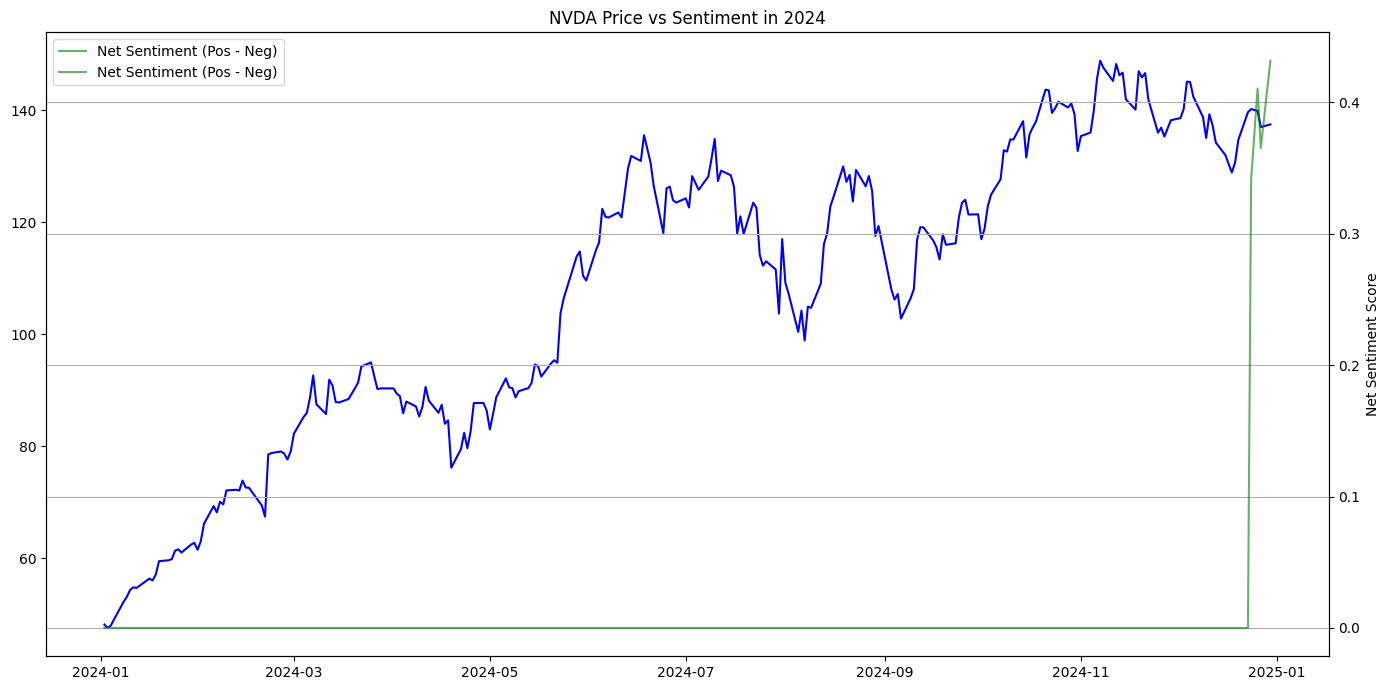

In [ ]:
import os
import pandas as pd
import datetime as dt
import finnhub
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import yfinance as yf
import matplotlib.pyplot as plt

# --------------------
# CONFIG
# --------------------
FINNHUB_API_KEY = "d2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0"
SYMBOL = "NVDA"
YEAR = 2025
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------
# Finnhub client
# --------------------
client = finnhub.Client(api_key=FINNHUB_API_KEY)

# --------------------
# Step 1: Fetch company news from Finnhub
# --------------------
year_start = f"{YEAR}-01-01"
year_end = f"{YEAR}-04-31"
print(f"Fetching {SYMBOL} company news from Finnhub for {YEAR}...")
news = client.company_news(SYMBOL, _from=year_start, to=year_end)
df_news = pd.DataFrame(news)
print(f"Fetched {len(df_news)} news items.")

# Keep only relevant fields
df_news = df_news[["datetime", "headline", "summary"]]
df_news["date"] = pd.to_datetime(df_news["datetime"], unit="s").dt.date
df_news.drop(columns=["datetime"], inplace=True)

# --------------------
# Step 2: Load FinBERT model for sentiment scoring
# --------------------
print("Loading FinBERT model (this may take a while)...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)

def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = softmax(outputs.logits.cpu().numpy()[0])
    labels = ["negative", "neutral", "positive"]
    return dict(zip(labels, probs))

print("Scoring sentiment for each news item (using FinBERT)...")
df_news["sentiment"] = df_news["headline"].fillna("").apply(get_sentiment)
df_news["sent_pos"] = df_news["sentiment"].apply(lambda x: x["positive"])
df_news["sent_neu"] = df_news["sentiment"].apply(lambda x: x["neutral"])
df_news["sent_neg"] = df_news["sentiment"].apply(lambda x: x["negative"])
df_news.drop(columns=["sentiment"], inplace=True)

# --------------------
# Step 3: Fetch daily OHLCV prices from yfinance
# --------------------
print(f"Fetching daily price data for {SYMBOL} from yfinance...")
df_price = yf.download(SYMBOL, start=year_start, end=year_end, interval="1d")
df_price.reset_index(inplace=True)
df_price["date"] = df_price["Date"].dt.date
df_price.drop(columns=["Date"], inplace=True)
df_price.columns = [col[0] if isinstance(col, tuple) else col for col in df_price.columns]
df_price.columns = [col.lower() for col in df_price.columns]

# --------------------
# Step 4: Merge sentiment with prices
# --------------------
print("Merging sentiment data with daily prices...")
df_sentiment_daily = df_news.groupby("date")[["sent_pos", "sent_neu", "sent_neg"]].mean().reset_index()

# Compute net sentiment score = positive - negative
df_sentiment_daily["net_sentiment"] = df_sentiment_daily["sent_pos"] - df_sentiment_daily["sent_neg"]

df_merged = pd.merge(df_price, df_sentiment_daily, on="date", how="left")
df_merged.fillna(0, inplace=True)

# --------------------
# Step 5: Save final dataset
# --------------------
output_file = f"{SYMBOL}_2024_sentiment_prices.csv"
df_merged.to_csv(output_file, index=False)
print(f"Saved merged dataset to {output_file}")

# --------------------
# Step 6: Plot price vs sentiment
# --------------------
plt.figure(figsize=(14, 7))

# Price on left y-axis
print(df_merged)
plt.plot(df_merged["date"], df_merged["close"], color="blue", label="Closing Price (USD)")

# Sentiment on right y-axis
ax2 = plt.gca().twinx()
ax2.plot(df_merged["date"], df_merged["net_sentiment"], color="green", label="Net Sentiment (Pos - Neg)", alpha=0.6)

# Labels and legend
plt.title(f"{SYMBOL} Price vs Sentiment in {YEAR}")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
ax2.set_ylabel("Net Sentiment Score")
plt.grid(True)

# Handle legends from both axes
lines_1, labels_1 = plt.gca().get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
import os
import time
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import finnhub
import yfinance as yf
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from pandas.tseries.offsets import BDay


# -------------------------
# CONFIG
# -------------------------
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'
if not FINNHUB_API_KEY:
    raise RuntimeError("Set FINNHUB_API_KEY environment variable before running.")

SYMBOL = "NVDA"
YEAR_START = "2025-01-01"
YEAR_END = "2025-04-30"   # April has 30 days
LAGS_DAYS = [1, 3, 7, 14, 30]   # lags to evaluate (in days)
OUT_DIR = "./nvda_finnhub_impact_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Initialize Finnhub client
# -------------------------
client = finnhub.Client(api_key=FINNHUB_API_KEY)

# -------------------------
# 1) Fetch company news from Finnhub
# -------------------------



print(f"Fetching {SYMBOL} news from {YEAR_START} → {YEAR_END} in weekly batches...")

start = datetime.strptime(YEAR_START, "%Y-%m-%d")
end = datetime.strptime(YEAR_END, "%Y-%m-%d")
delta = timedelta(days=7)

all_news = []

while start <= end:
    batch_end = min(start + delta, end)
    try:
        news_batch = client.company_news(
            SYMBOL,
            _from=start.strftime("%Y-%m-%d"),
            to=batch_end.strftime("%Y-%m-%d")
        )
        if news_batch:
            all_news.extend(news_batch)
            print(f"Fetched {len(news_batch)} items from {start.date()} → {batch_end.date()}")
        else:
            print(f"No items from {start.date()} → {batch_end.date()}")
    except Exception as e:
        print(f"Error fetching news for {start.date()} → {batch_end.date()}: {e}")
    start = batch_end + timedelta(days=1)
    time.sleep(0.25)  # avoid API rate limits

# Convert to DataFrame and clean
df_news = pd.DataFrame(all_news)
if df_news.empty:
    raise RuntimeError("No news returned from Finnhub for the range. Check API key / subscription / ticker.")

df_news = df_news.rename(columns={"datetime": "unix_ts"})

# Drop rows with null or impossible timestamps
df_news = df_news[pd.to_numeric(df_news["unix_ts"], errors="coerce").notna()]
df_news = df_news[df_news["unix_ts"] > 1000000000]  # keep only timestamps after ~2001

# Convert valid timestamps (unit = seconds)
df_news["published_at"] = pd.to_datetime(df_news["unix_ts"], unit="s", utc=True, errors="coerce")
df_news = df_news[df_news["published_at"].notna()]

df_news["pub_date"] = df_news["published_at"].dt.date

df_news["text"] = (
    df_news["headline"].fillna("") + ". " + df_news.get("summary", "").fillna("")
).str.strip()

df_news = df_news[["id", "published_at", "pub_date", "headline", "summary", "url", "text"]]
df_news = df_news.drop_duplicates(subset=["id"]).reset_index(drop=True)

print(f"Total unique valid news items: {len(df_news)}")
print("News date range:", df_news['pub_date'].min(), "→", df_news['pub_date'].max())

news_csv = os.path.join(OUT_DIR, "nvda_news_raw.csv")
df_news.to_csv(news_csv, index=False)
print("Saved raw news ->", news_csv)
# -------------------------
# 2) Sentiment scoring (FinBERT)
# -------------------------
print("Loading FinBERT (ProsusAI/finbert)... this may take a bit.")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)

def sentiment_score_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return (0.0, 0.0, 1.0, 0.0)   # neutral fallback
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = model(**inputs)
    probs = softmax(out.logits.cpu().numpy()[0])
    neg, neu, pos = float(probs[0]), float(probs[1]), float(probs[2])
    return (pos - neg, pos, neu, neg)

print("Scoring sentiment for each news item (headline+summary)...")
sent_net = []
sent_pos = []
sent_neu = []
sent_neg = []
for txt in df_news["text"].tolist():
    s_net, p, n, g = sentiment_score_text(txt)
    sent_net.append(s_net)
    sent_pos.append(p)
    sent_neu.append(n)
    sent_neg.append(g)

df_news["sent_net"] = sent_net
df_news["sent_pos"] = sent_pos
df_news["sent_neu"] = sent_neu
df_news["sent_neg"] = sent_neg

sent_csv = os.path.join(OUT_DIR, "nvda_news_with_sentiment.csv")
df_news.to_csv(sent_csv, index=False)
print("Saved news with sentiment ->", sent_csv)


Fetching NVDA news from 2025-01-01 → 2025-04-30 in weekly batches...
Fetched 234 items from 2025-01-01 → 2025-01-08
Fetched 198 items from 2025-01-09 → 2025-01-16
Fetched 103 items from 2025-01-17 → 2025-01-24
Fetched 182 items from 2025-01-25 → 2025-02-01
Fetched 165 items from 2025-02-02 → 2025-02-09
Fetched 160 items from 2025-02-10 → 2025-02-17
Fetched 152 items from 2025-02-18 → 2025-02-25
Fetched 247 items from 2025-02-26 → 2025-03-05
Fetched 198 items from 2025-03-06 → 2025-03-13
Fetched 237 items from 2025-03-14 → 2025-03-21
Fetched 226 items from 2025-03-22 → 2025-03-29
Fetched 238 items from 2025-03-30 → 2025-04-06
Fetched 238 items from 2025-04-07 → 2025-04-14
Fetched 238 items from 2025-04-15 → 2025-04-22
Fetched 231 items from 2025-04-23 → 2025-04-30
Total unique valid news items: 3045
News date range: 2024-11-08 → 2025-04-30
Saved raw news -> ./nvda_finnhub_impact_outputs/nvda_news_raw.csv
Loading FinBERT (ProsusAI/finbert)... this may take a bit.
Scoring sentiment for ea

KeyError: 'date'

In [ ]:

# -------------------------
# 3) Fetch daily prices from yfinance (cover extended window)
# -------------------------
start_dt = (pd.to_datetime(YEAR_START) - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
end_dt = (pd.to_datetime(YEAR_END) + pd.Timedelta(days=max(LAGS_DAYS) + 5)).strftime("%Y-%m-%d")

max_news_date = df_news["date"].max()
needed_end_date = pd.to_datetime(max_news_date) + BDay(40)

print("Downloading daily prices from yfinance:", start_dt, "→", needed_end_date.strftime('%Y-%m-%d'))

df_price = yf.download(SYMBOL, start=start_dt, end=needed_end_date.strftime('%Y-%m-%d'), interval="1d")
df_price.reset_index(inplace=True)

if isinstance(df_price.columns, pd.MultiIndex):
    df_price.columns = [col[0].lower() for col in df_price.columns]
else:
    df_price.columns = [col.lower() for col in df_price.columns]

# Keep date as Timestamp (not datetime.date)
df_price["date"] = pd.to_datetime(df_price["date"])
df_price = df_price[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)

prices_csv = os.path.join(OUT_DIR, "nvda_prices_daily.csv")
df_price.to_csv(prices_csv, index=False)
print("Saved daily prices ->", prices_csv)


# -------------------------
# 4) Compute lagged pct changes per news article using your helper approach
# -------------------------

print("Computing lagged returns for each news item...")

# Ensure date formats for news
df_news['pub_date'] = pd.to_datetime(df_news['date'])
df_price['date'] = pd.to_datetime(df_price['date'])
df_price = df_price.sort_values('date').reset_index(drop=True)

# Price lookup map
price_map = df_price.set_index('date')['close']

def compute_pct_change(pub_date):
    result = {}
    try:
        base_date = df_price.loc[df_price['date'] >= pub_date, 'date'].iloc[0]
        base_price = price_map.loc[base_date]
    except IndexError:
        return None

    result['pub_date'] = pub_date
    for lag in LAGS_DAYS:
        idx = df_price.index[df_price['date'] == base_date][0]
        future_idx = idx + lag
        if future_idx < len(df_price):
            price_future = df_price.iloc[future_idx]['close']
            result[f'pct_change_{lag}d'] = (price_future - base_price) / base_price
        else:
            result[f'pct_change_{lag}d'] = np.nan
    return result

rows = []
for _, art in df_news.iterrows():
    r = compute_pct_change(art['pub_date'])
    if r is not None:
        r.update({
            'headline': art['headline'],
            'sent_net': art['sent_net'],
            'sent_pos': art['sent_pos'],
            'sent_neu': art['sent_neu'],
            'sent_neg': art['sent_neg'],
            'published_at': art['published_at'],
            'id': art['id'],
            'url': art['url']
        })
        rows.append(r)

df_results = pd.DataFrame(rows)

def best_lag(row):
    vals = {lag: row[f'pct_change_{lag}d'] for lag in LAGS_DAYS if pd.notna(row[f'pct_change_{lag}d'])}
    if not vals:
        return (np.nan, np.nan)
    best = max(vals, key=lambda d: abs(vals[d]))
    return best, vals[best]

df_results[['best_lag_days','best_lag_pct_change']] = df_results.apply(lambda r: pd.Series(best_lag(r)), axis=1)

results_csv = os.path.join(OUT_DIR, "nvda_news_lagged_results.csv")
df_results.to_csv(results_csv, index=False)
print(f"Saved per-article lagged results -> {results_csv}")
print(f"Processed articles: {len(df_results)}")

# -------------------------
# 5) Analysis: correlation, regression, directional accuracy
# -------------------------
print("Analyzing results by lag...")
summary_rows = []

for lag in LAGS_DAYS:
    col = f"pct_change_{lag}d"

    if "sent_net" not in df_results.columns or col not in df_results.columns:
        print(f"Skipping lag {lag}d — missing data.")
        continue

    tmp = df_results[["sent_net", col]].dropna()
    n = len(tmp)

    if n >= 5:
        r_val, p_val = stats.pearsonr(tmp["sent_net"], tmp[col])
        X = tmp[["sent_net"]].values.reshape(-1, 1)
        y = tmp[col].values
        lr = LinearRegression().fit(X, y)
        coef = float(lr.coef_[0])
        intercept = float(lr.intercept_)
        r2 = float(lr.score(X, y))
    else:
        r_val = p_val = coef = intercept = r2 = np.nan

    tmp_dir = tmp.copy()
    tmp_dir = tmp_dir.assign(
        sent_dir=np.sign(tmp_dir["sent_net"]),
        price_dir=np.sign(tmp_dir[col])
    )
    tmp_dir = tmp_dir[tmp_dir["sent_dir"] != 0]
    accuracy = (tmp_dir["sent_dir"] == tmp_dir["price_dir"]).mean() if len(tmp_dir) > 0 else np.nan

    summary_rows.append({
        "lag_days": lag,
        "n": n,
        "pearson_r": r_val,
        "p_value": p_val,
        "reg_coef": coef,
        "reg_intercept": intercept,
        "reg_r2": r2,
        "directional_accuracy": accuracy
    })

df_summary = pd.DataFrame(summary_rows).sort_values("lag_days")

if not df_summary.empty:
    summary_csv = os.path.join(OUT_DIR, "nvda_lag_summary.csv")
    df_summary.to_csv(summary_csv, index=False)
    print("Saved lag summary ->", summary_csv)
    print(df_summary)
else:
    print("No valid lag results to save.")

# -------------------------
# 6) Plots
# -------------------------
plt.figure(figsize=(8,5))
plt.bar(
    df_summary["lag_days"].astype(str),       # x-axis labels
    df_summary["directional_accuracy"]        # heights of the bars
)
plt.xlabel("Lag (days)")
plt.ylabel("Directional accuracy (fraction)")
plt.title("Direction accuracy of sentiment prediction by lag")
plt.grid(axis="y")
plt.savefig(os.path.join(OUT_DIR, "directional_accuracy_by_lag.png"), dpi=200)
plt.close()

In [145]:
print("News date range:", df_news['pub_date'].min(), "→", df_news['pub_date'].max())

News date range: 2025-04-24 00:00:00 → 2025-04-30 00:00:00


In [124]:
"""
nvda_finnhub_impact_tracker.py

- Fetch NVDA company news from Finnhub (Jan 1, 2025 -> Apr 30, 2025)
- Score sentiment with FinBERT (ProsusAI/finbert) on headline+summary
- Fetch daily OHLCV from yfinance (covering lag windows)
- Compute percent changes at multiple day lags and directional accuracy
- Compute correlation/regression per lag and save results + plots
"""

import os
import time
from datetime import datetime, timedelta, date
import pandas as pd
import numpy as np
import finnhub
import yfinance as yf
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from pandas.tseries.offsets import BDay


# -------------------------
# CONFIG
# -------------------------
FINNHUB_API_KEY = 'd2arrjpr01qgk9ugd2ugd2arrjpr01qgk9ugd2v0'
if not FINNHUB_API_KEY:
    raise RuntimeError("Set FINNHUB_API_KEY environment variable before running.")

SYMBOL = "NVDA"
YEAR_START = "2025-01-01"
YEAR_END = "2025-04-30"   # April has 30 days
LAGS_DAYS = [1, 3, 7, 14, 30]   # lags to evaluate (in days)
OUT_DIR = "./nvda_finnhub_impact_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Initialize Finnhub client
# -------------------------
client = finnhub.Client(api_key=FINNHUB_API_KEY)

# -------------------------
# 1) Fetch company news from Finnhub
# -------------------------
print(f"Fetching company news from Finnhub for {SYMBOL}: {YEAR_START} → {YEAR_END} ...")
news = client.company_news(SYMBOL, _from=YEAR_START, to=YEAR_END)
time.sleep(0.2)
df_news = pd.DataFrame(news)

print("Raw news count:", len(df_news))
if df_news.empty:
    raise RuntimeError("No news returned from Finnhub for the range. Check your API key / subscription / ticker.")

# Normalize fields
df_news = df_news.rename(columns={"datetime": "unix_ts"})
df_news["published_at"] = pd.to_datetime(df_news["unix_ts"], unit="s", utc=True)
df_news["date"] = df_news["published_at"].dt.date
df_news["text"] = (df_news["headline"].fillna("") + ". " + df_news.get("summary", "").fillna("")).str.strip()
df_news = df_news[["id","published_at","date","headline","summary","url","text"]].drop_duplicates(subset=["id"]).reset_index(drop=True)

raw_news_csv = os.path.join(OUT_DIR, "nvda_news_raw.csv")
df_news.to_csv(raw_news_csv, index=False)
print("Saved raw news ->", raw_news_csv)

# -------------------------
# 2) Sentiment scoring (FinBERT)
# -------------------------
print("Loading FinBERT (ProsusAI/finbert)... this may take a bit.")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)

def sentiment_score_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return (0.0, 0.0, 1.0, 0.0)   # neutral fallback
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = model(**inputs)
    probs = softmax(out.logits.cpu().numpy()[0])
    neg, neu, pos = float(probs[0]), float(probs[1]), float(probs[2])
    return (pos - neg, pos, neu, neg)

print("Scoring sentiment for each news item (headline+summary)...")
sent_net = []
sent_pos = []
sent_neu = []
sent_neg = []
for txt in df_news["text"].tolist():
    s_net, p, n, g = sentiment_score_text(txt)
    sent_net.append(s_net)
    sent_pos.append(p)
    sent_neu.append(n)
    sent_neg.append(g)

df_news["sent_net"] = sent_net
df_news["sent_pos"] = sent_pos
df_news["sent_neu"] = sent_neu
df_news["sent_neg"] = sent_neg

sent_csv = os.path.join(OUT_DIR, "nvda_news_with_sentiment.csv")
df_news.to_csv(sent_csv, index=False)
print("Saved news with sentiment ->", sent_csv)

# -------------------------
# 3) Fetch daily prices from yfinance (cover extended window)
# -------------------------
# fetch a little before and after in case lags land outside
start_dt = (pd.to_datetime(YEAR_START) - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
end_dt = (pd.to_datetime(YEAR_END) + pd.Timedelta(days=max(LAGS_DAYS) + 5)).strftime("%Y-%m-%d")

# Latest news date
max_news_date = df_news["date"].max()

# Add 40 business days (more than 30 to be safe)
needed_end_date = max_news_date + BDay(40)


print("Downloading daily prices from yfinance:", start_dt, "→", end_dt)

# Use updated date range here:
df_price = yf.download(SYMBOL, start=start_dt, end=needed_end_date.strftime('%Y-%m-%d'), interval="1d")

# Reset index so Date is a column
df_price.reset_index(inplace=True)

# Flatten multi-index columns if present
if isinstance(df_price.columns, pd.MultiIndex):
    df_price.columns = [col[0].lower() for col in df_price.columns]
else:
    df_price.columns = [col.lower() for col in df_price.columns]

# Rename 'date' column correctly if needed
if "date" not in df_price.columns and "datetime" in df_price.columns:
    df_price.rename(columns={"datetime": "date"}, inplace=True)

# Ensure 'date' column is date type (not datetime)
df_price["date"] = pd.to_datetime(df_price["date"]).dt.date

# Keep only necessary columns and sort
df_price = df_price[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)

prices_csv = os.path.join(OUT_DIR, "nvda_prices_daily.csv")
df_price.to_csv(prices_csv, index=False)
print("Saved daily prices ->", prices_csv)

# # helper functions for trading dates/prices
# def get_trading_date_on_or_after(d):
#     arr = df_price[df_price["date"] >= d]
#     if arr.shape[0] == 0:
#         return None
#     return arr.iloc[0]["date"]

# def get_close_on_date(d):
#     r = df_price[df_price["date"] == d]
#     if len(r) == 0:
#         return None
#     return float(r.iloc[0]["close"])

# -------------------------
# 4) Compute lagged pct changes per news article
# -------------------------
# Ensure price dataframe is sorted and trading_dates list is clean
df_price["date"] = pd.to_datetime(df_price["date"])

df_price = df_price.sort_values("date").reset_index(drop=True)
trading_dates = list(sorted(df_price["date"].unique()))

def get_trading_date_on_or_after(input_date):
    input_date = pd.Timestamp(input_date)
    for d in trading_dates:
        if d >= input_date:
            return d
    return None

def get_close_on_date(date):
    match = df_price.loc[df_price["date"] == date, "close"]
    if len(match) == 0:
        return None
    return float(match.iloc[0])

def add_trading_days(start_date, days):
    if start_date not in trading_dates:
        start_date = get_trading_date_on_or_after(start_date)
    if start_date is None:
        return None
    try:
        start_idx = trading_dates.index(start_date)
    except ValueError:
        return None
    target_idx = start_idx + days
    if target_idx >= len(trading_dates):
        return None
    return trading_dates[target_idx]

records = []
price_min_date = df_price["date"].min()
price_max_date = df_price["date"].max()
print(f"Price data covers from {price_min_date.date()} to {price_max_date.date()}")

for _, r in df_news.iterrows():
    pub_date = pd.to_datetime(r["date"])
    if pub_date < price_min_date:
        print(f"Warning: News date {pub_date.date()} before price data start {price_min_date.date()}. Skipping.")
        continue
    if pub_date > price_max_date:
        print(f"Warning: News date {pub_date.date()} after price data end {price_max_date.date()}. Skipping.")
        continue

    base_td = get_trading_date_on_or_after(pub_date)
    if base_td is None:
        print(f"Warning: No trading date found on/after news date {pub_date.date()}. Skipping.")
        continue
    base_close = get_close_on_date(base_td)
    if base_close is None:
        print(f"Warning: No close price for base trading date {base_td.date()}. Skipping.")
        continue

    rec = {
        "id": r.get("id", None),
        "published_at": r.get("published_at", None),
        "pub_date": pub_date,
        "base_trading_date": base_td,
        "base_close": base_close,
        "sent_net": r["sent_net"],
        "sent_pos": r["sent_pos"],
        "sent_neu": r["sent_neu"],
        "sent_neg": r["sent_neg"],
        "headline": r.get("headline", ""),
        "url": r.get("url", "")
    }

    for lag in LAGS_DAYS:
        target_date = add_trading_days(base_td, lag)
        if target_date is None:
            print(f"Note: Lag {lag}d out of range for article on {pub_date.date()}.")
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        close_price = get_close_on_date(target_date)
        if close_price is None:
            print(f"Warning: No price for lag {lag}d date {target_date.date()} (article {pub_date.date()}).")
            rec[f"close_{lag}d"] = np.nan
            rec[f"pct_change_{lag}d"] = np.nan
            rec[f"trading_date_{lag}d"] = None
            continue

        rec[f"close_{lag}d"] = close_price
        rec[f"pct_change_{lag}d"] = (close_price - base_close) / base_close
        rec[f"trading_date_{lag}d"] = target_date

    # Determine best lag
    lag_changes = {
        lag: rec[f"pct_change_{lag}d"]
        for lag in LAGS_DAYS
        if pd.notna(rec[f"pct_change_{lag}d"])
    }
    if lag_changes:
        best_lag = max(lag_changes, key=lambda d: abs(lag_changes[d]))
        rec["best_lag_days"] = best_lag
        rec["best_lag_pct_change"] = lag_changes[best_lag]
    else:
        rec["best_lag_days"] = np.nan
        rec["best_lag_pct_change"] = np.nan

    records.append(rec)

df_results = pd.DataFrame(records)
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results.csv"), index=False)
print(f"Saved per-article lagged results.")
print(f"Processed articles: {len(df_results)}")
# -------------------------
# 5) Analysis: correlation, regression, directional accuracy
# -------------------------
print("Analyzing results by lag...")
summary_rows = []

for lag in LAGS_DAYS:
    col = f"pct_change_{lag}d"

    # Skip if required columns don't exist
    if "sent_net" not in df_results.columns or col not in df_results.columns:
        print(f"Skipping lag {lag}d — missing 'sent_net' or '{col}' in df_results.")
        continue

    tmp = df_results[["sent_net", col]].dropna()
    n = len(tmp)

    if n >= 5:
        r_val, p_val = stats.pearsonr(tmp["sent_net"], tmp[col])
        X = tmp[["sent_net"]].values.reshape(-1, 1)
        y = tmp[col].values
        lr = LinearRegression().fit(X, y)
        coef = float(lr.coef_[0])
        intercept = float(lr.intercept_)
        r2 = float(lr.score(X, y))
    else:
        r_val = p_val = coef = intercept = r2 = np.nan

    # Directional accuracy
    tmp_dir = tmp.copy()
    tmp_dir = tmp_dir.assign(
        sent_dir=np.sign(tmp_dir["sent_net"]),
        price_dir=np.sign(tmp_dir[col])
    )
    tmp_dir = tmp_dir[tmp_dir["sent_dir"] != 0]
    accuracy = (tmp_dir["sent_dir"] == tmp_dir["price_dir"]).mean() if len(tmp_dir) > 0 else np.nan

    summary_rows.append({
        "lag_days": lag,
        "n": n,
        "pearson_r": r_val,
        "p_value": p_val,
        "reg_coef": coef,
        "reg_intercept": intercept,
        "reg_r2": r2,
        "directional_accuracy": accuracy
    })

df_summary = pd.DataFrame(summary_rows).sort_values("lag_days")

if not df_summary.empty:
    summary_csv = os.path.join(OUT_DIR, "nvda_lag_summary.csv")
    df_summary.to_csv(summary_csv, index=False)
    print("Saved lag summary ->", summary_csv)
    print(df_summary)
else:
    print("No valid lag results to save.")

# -------------------------
# 6) Per-article best lag (largest absolute pct move) and save
# -------------------------
lag_cols = [f"pct_change_{lag}d" for lag in LAGS_DAYS]
print("Lag columns example data:")
print(df_results[[f"pct_change_{lag}d" for lag in LAGS_DAYS]].head())

def best_lag_info(row):
    vals = row[[f"pct_change_{lag}d" for lag in LAGS_DAYS]].abs()
    vals = vals.dropna()
    if vals.empty:
        return (None, np.nan)
    best_col = vals.idxmax()
    best_lag = int(best_col.split("_")[2].replace("d",""))
    best_val = row[best_col]
    return (best_lag, best_val)

df_results["best_lag_days"] = df_results.apply(lambda r: best_lag_info(r)[0], axis=1)
df_results["best_lag_pct_change"] = df_results.apply(lambda r: best_lag_info(r)[1], axis=1)

print("After computing best lag info:")
print(df_results[["best_lag_days", "best_lag_pct_change"]].head(10))
df_results.to_csv(os.path.join(OUT_DIR, "nvda_news_lagged_results_with_bestlag.csv"), index=False)
print("Saved per-article best-lag file.")

# -------------------------
# 7) Plots: correlation vs lag & directional accuracy vs lag
# -------------------------
# correlation plot
plt.figure(figsize=(8,5))
plt.plot(df_summary["lag_days"], df_summary["pearson_r"], marker="o")
plt.xlabel("Lag after news (days)")
plt.ylabel("Pearson correlation (sent_net vs pct_change)")
plt.title("NVDA: sentiment vs pct change correlation by lag")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "correlation_vs_lag.png"), dpi=200)
plt.close()

# directional accuracy bar
plt.figure(figsize=(8,5))
plt.bar(df_summary["lag_days"].astype(str), df_summary["directional_accuracy"])
plt.xlabel("Lag (days)")
plt.ylabel("Directional accuracy (fraction)")
plt.title("Direction accuracy of sentiment prediction by lag")
plt.grid(axis="y")
plt.savefig(os.path.join(OUT_DIR, "directional_accuracy_by_lag.png"), dpi=200)
plt.close()

print("Plots saved in", OUT_DIR)
print("Done.")

Fetching company news from Finnhub for NVDA: 2025-01-01 → 2025-04-30 ...
Raw news count: 231
Saved raw news -> ./nvda_finnhub_impact_outputs/nvda_news_raw.csv
Loading FinBERT (ProsusAI/finbert)... this may take a bit.
Scoring sentiment for each news item (headline+summary)...


/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_12846/2181239413.py:126: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download(SYMBOL, start=start_dt, end=needed_end_date.strftime('%Y-%m-%d'), interval="1d")
[*********************100%***********************]  1 of 1 completed

Saved news with sentiment -> ./nvda_finnhub_impact_outputs/nvda_news_with_sentiment.csv
Saved daily prices -> ./nvda_finnhub_impact_outputs/nvda_prices_daily.csv
Price data covers from 2024-12-27 to 2025-06-24
Saved per-article lagged results.
Processed articles: 231
Analyzing results by lag...
Saved lag summary -> ./nvda_finnhub_impact_outputs/nvda_lag_summary.csv
   lag_days    n  pearson_r   p_value  reg_coef  reg_intercept    reg_r2  \
0         1  231  -0.007117  0.914331 -0.000223       0.005319  0.000051   
1         3  231   0.143317  0.029431  0.006323       0.026503  0.020540   
2         7  231   0.180870  0.005836  0.006663       0.063249  0.032714   
3        14  231   0.091078  0.167703  0.002190       0.236479  0.008295   
4        30  231   0.101749  0.123059  0.003108       0.315569  0.010353   

   directional_accuracy  
0              0.571429  
1              0.670996  
2              0.688312  
3              0.688312  
4              0.688312  
Lag columns example

After computing best lag info:
   best_lag_days  best_lag_pct_change
0             30             0.331345
1             30             0.331345
2             30             0.331345
3             30             0.331345
4             30             0.331345
5             30             0.331345
6             30             0.331345
7             30             0.331345
8             30             0.331345
9             30             0.331345
Saved per-article best-lag file.
Plots saved in ./nvda_finnhub_impact_outputs
Done.


In [144]:
print(df_results[["pub_date", "pct_change_1d", "pct_change_3d", 
                  "pct_change_7d", "pct_change_14d", "pct_change_30d"]].head(20))

     pub_date  pct_change_1d  pct_change_3d  pct_change_7d  pct_change_14d  \
0  2025-04-30       0.024697       0.044987        0.07097         0.23375   
1  2025-04-30       0.024697       0.044987        0.07097         0.23375   
2  2025-04-30       0.024697       0.044987        0.07097         0.23375   
3  2025-04-30       0.024697       0.044987        0.07097         0.23375   
4  2025-04-30       0.024697       0.044987        0.07097         0.23375   
5  2025-04-30       0.024697       0.044987        0.07097         0.23375   
6  2025-04-30       0.024697       0.044987        0.07097         0.23375   
7  2025-04-30       0.024697       0.044987        0.07097         0.23375   
8  2025-04-30       0.024697       0.044987        0.07097         0.23375   
9  2025-04-30       0.024697       0.044987        0.07097         0.23375   
10 2025-04-30       0.024697       0.044987        0.07097         0.23375   
11 2025-04-30       0.024697       0.044987        0.07097      

In [143]:
import random
import pandas as pd
import os

summary_txt_path = os.path.join(OUT_DIR, "nvda_summary_report.txt")

with open(summary_txt_path, "w", encoding="utf-8") as f:
    def write_and_print(line=""):
        print(line)
        f.write(line + "\n")

    write_and_print("=== NVDA Stock Sentiment Impact Summary ===\n")

    # Check if lag summary exists
    if not df_summary.empty:
        # Find lag with strongest absolute correlation
        best_row = df_summary.loc[df_summary['pearson_r'].abs().idxmax()]
        best_corr_lag = int(best_row["lag_days"])
        best_corr_val = best_row["pearson_r"]

        write_and_print(
            f"Overall, the strongest correlation between news sentiment "
            f"and stock price change is at a lag of {best_corr_lag} trading days."
        )
        write_and_print(f"Correlation coefficient at this lag: {best_corr_val:.3f}\n")
    else:
        write_and_print("No valid lag correlation results to summarize.\n")

    # Filter articles with valid best lag and price impact
    valid_articles = df_results.dropna(subset=["best_lag_days", "best_lag_pct_change"])
    write_and_print(f"Number of articles with valid impact data: {len(valid_articles)}\n")

    if len(valid_articles) == 0:
        write_and_print("No articles with valid impact data to show examples.\n")
    else:
        # Randomly sample up to 5 examples each run
        sample_size = min(5, len(valid_articles))
        examples = valid_articles.sample(sample_size, random_state=None)

        write_and_print(f"Showing {sample_size} example news impacts:\n")

        for _, row in examples.iterrows():
            try:
                best_lag_days = int(row["best_lag_days"])
                trading_date_col = f"trading_date_{best_lag_days}d"
                pct_change_col = f"pct_change_{best_lag_days}d"

                pub_date = pd.to_datetime(row["pub_date"]).date()
                impact_date = row.get(trading_date_col, None)
                impact_pct = row.get(pct_change_col, None)

                write_and_print(f"- News Date: {pub_date}")
                if pd.notnull(impact_date):
                    write_and_print(f"  Impact Date ({best_lag_days} trading days later): {pd.to_datetime(impact_date).date()}")
                else:
                    write_and_print(f"  Impact Date ({best_lag_days} trading days later): N/A")

                write_and_print(f"  Headline: {row.get('headline', 'N/A')}")

                if pd.notnull(impact_pct):
                    write_and_print(f"  Price Change: {impact_pct*100:.2f}%\n")
                else:
                    write_and_print("  Price Change: N/A (no data)\n")
            except Exception as e:
                write_and_print(f"  Skipped an example due to error: {e}\n")

    write_and_print(
        "Note: Price change is calculated as the percentage change in closing price "
        "relative to the closing price on or just after the news publication date."
    )
    write_and_print(
        "The impact delay (lag) indicates how many trading days after news publication "
        "the stock price shows the strongest per-article reaction."
    )

    write_and_print(f"\nDetailed impact summary saved to: {summary_txt_path}")


=== NVDA Stock Sentiment Impact Summary ===

Overall, the strongest correlation between news sentiment and stock price change is at a lag of 7 trading days.
Correlation coefficient at this lag: 0.181

Number of articles with valid impact data: 231

Showing 5 example news impacts:

- News Date: 2025-04-28
  Impact Date (30 trading days later): N/A
  Headline: Nvidia stock falls as China's Huawei reportedly readies AI chip after Trump's export ban
  Price Change: 32.40%

- News Date: 2025-04-30
  Impact Date (30 trading days later): N/A
  Headline: Trump’s Next Move on Nvidia Could Be a Costly Mistake
  Price Change: 33.13%

- News Date: 2025-04-25
  Impact Date (30 trading days later): N/A
  Headline: 1 Wall Street Analyst Thinks Nvidia Stock Is Going to $150. Is It a Buy?
  Price Change: 28.48%

- News Date: 2025-04-30
  Impact Date (30 trading days later): N/A
  Headline: Billionaires Sell Nvidia Stock Before the Market Crash and Buy a Golden ETF Up 166% in 10 Years
  Price Change: 33

### using yahoo finance scraping

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import yfinance as yf
import matplotlib.pyplot as plt

# --------------------
# CONFIG
# --------------------
SYMBOL = "NVDA"
YEAR = 2024
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to the Selenium-scraped news CSV
SCRAPED_NEWS_CSV = "nvda_news_cache/nvda_yahoo_with_dates_text.csv"

# --------------------
# Load scraped news with full text
# --------------------
df_news = pd.read_csv(SCRAPED_NEWS_CSV, parse_dates=["date"])

# Drop rows where date or full_text is missing (can't score those)
df_news.dropna(subset=["date", "full_text"], inplace=True)

# Convert date to datetime.date (not datetime64) for grouping later
df_news["date"] = df_news["date"].dt.date

print(f"Loaded {len(df_news)} news articles with dates and full text.")

# --------------------
# Load FinBERT model
# --------------------
print("Loading FinBERT model...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE)

# --------------------
# Define sentiment scoring function (on full text)
# --------------------
def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = softmax(outputs.logits.cpu().numpy()[0])
    labels = ["negative", "neutral", "positive"]
    return dict(zip(labels, probs))

# --------------------
# Score sentiment for each article (full_text)
# --------------------
print("Scoring sentiment on full article text...")
df_news["sentiment"] = df_news["full_text"].apply(get_sentiment)

df_news["sent_pos"] = df_news["sentiment"].apply(lambda x: x["positive"])
df_news["sent_neu"] = df_news["sentiment"].apply(lambda x: x["neutral"])
df_news["sent_neg"] = df_news["sentiment"].apply(lambda x: x["negative"])

df_news.drop(columns=["sentiment"], inplace=True)

# --------------------
# Fetch daily prices from yfinance
# --------------------
print(f"Fetching daily price data for {SYMBOL} from yfinance...")
df_price = yf.download(SYMBOL, start=f"{YEAR}-01-01", end=f"{YEAR+1}-01-01", interval="1d")
df_price.reset_index(inplace=True)
df_price["date"] = df_price["Date"].dt.date
df_price.drop(columns=["Date"], inplace=True)
df_price.columns = [col.lower() for col in df_price.columns]

# --------------------
# Aggregate daily sentiment scores (mean)
# --------------------
df_sentiment_daily = df_news.groupby("date")[["sent_pos", "sent_neu", "sent_neg"]].mean().reset_index()
df_sentiment_daily["net_sentiment"] = df_sentiment_daily["sent_pos"] - df_sentiment_daily["sent_neg"]

# --------------------
# Merge daily sentiment with prices
# --------------------
df_merged = pd.merge(df_price, df_sentiment_daily, on="date", how="left")
df_merged.fillna(0, inplace=True)  # fill missing sentiment days with zero

# --------------------
# Save merged dataset
# --------------------
output_file = f"{SYMBOL}_2024_sentiment_prices_fulltext.csv"
df_merged.to_csv(output_file, index=False)
print(f"Saved merged dataset to {output_file}")

# --------------------
# Plot price vs net sentiment
# --------------------
import matplotlib.dates as mdates

plt.figure(figsize=(14, 7))

plt.plot(df_merged["date"], df_merged["close"], color="blue", label="Closing Price (USD)")
ax2 = plt.gca().twinx()
ax2.plot(df_merged["date"], df_merged["net_sentiment"], color="green", label="Net Sentiment (Pos - Neg)", alpha=0.6)

plt.title(f"{SYMBOL} Price vs Sentiment (Full Article Text) in {YEAR}")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
ax2.set_ylabel("Net Sentiment Score")

plt.grid(True)

# Format x-axis dates better
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Combine legends
lines_1, labels_1 = plt.gca().get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()